# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** 1

Caio Cordeiro Fabri - 2023027939

Carolina Penido Barcellos - 2024024054

Isadora Silva Drumond - 2024074485

Letícia Ribeiro Miranda - 2021095686

**Dataset:** Spotify Tracks Dataset

**Tarefa de mineração:** Agrupamento

**Data da entrega:** 24/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Spotify Tracks Dataset |
| Link público do dataset | https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset |
| Número de linhas | 114 001 |
| Número de colunas | 21 |
| Tarefa de mineração | Agrupamento |
| LLM usada na Trilha A |Gemini Pro|
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | https://gemini.google.com/share/3a350162bbfa|
| Link da conversa — Trilha B | https://gemini.google.com/share/1797e0a9b2ad|

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Monitoramento e Avaliação | É essencial avaliar a qualidade dos agrupamentos de maneira criteriosa, utilizando métricas quantitativas e análises comparativas para confirmar se os clusters realmente representam padrões relevantes nos dados musicais.| O prompt conterá a cláusula: Considere explicitamente as seguintes diretrizes de IA responsável - Monitoramento e Avaliação: avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas e propondo uma comparação rigorosa entre o desempenho de diferentes algoritmos. |
| Explicabilidade |  Essa diretriz garante que seja possível compreender e explicar os agrupamentos encontrados a partir das características predominantes das músicas (como energy, danceability, acousticness e valence), conectando os resultados a perfis musicais reais. | O prompt conterá a cláusula: Considere explicitamente as seguintes diretrizes de IA responsável - Explicabilidade: justifique os parâmetros utilizados e produza descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, de modo que os grupos façam sentido como perfis musicais reais.|

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [1]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "dados/dataset.csv"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "agrupamento"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = None # 

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: agrupamento


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

Neste trabalho, investigaremos o problema de como identificar padrões musicais ocultos e descobrir perfis de faixas semelhantes a partir de características sonoras e acústicas de milhares de músicas
. O dataset escolhido, o Spotify Tracks Dataset, é altamente relevante pois reflete um cenário real de ampla aplicação prática, possuindo variáveis numéricas (como danceability, energy e acousticness) que são ideais para a exploração de conceitos de mineração de dados
. A tarefa principal será o aprendizado não supervisionado, com aplicação de algoritmos de clusterização.

O valor esperado da análise é gerar clusters coerentes que auxiliem na compreensão das relações entre atributos sonoros e popularidade das músicas. Para isso, foram escolhidas as diretrizes de IA Responsável de Monitoramento e Avaliação e Explicabilidade, consideradas pertinentes por garantirem uma avaliação criteriosa dos agrupamentos e interpretações mais claras dos resultados. Espera-se que, ao explicitar essas diretrizes para a LLM, as respostas apresentem comparações mais rigorosas entre algoritmos, utilização de métricas quantitativas adequadas e descrições semânticas mais interpretáveis dos clusters.

- **Contexto:** O crescimento acelerado das plataformas de streaming musical gerou volumes massivos de dados relacionados às características sonoras das músicas. Lidar com esse grande catálogo de faixas exige inteligência computacional para categorizar e entender o que faz músicas serem acusticamente parecidas.
- **Problema:** A dificuldade de agrupar de forma automática faixas com perfis sonoros e comportamentais semelhantes independentemente de rótulos pré-definidos (como o gênero informado). É necessário identificar como atributos acústicos se relacionam com a popularidade e formar grupos naturais consistentes.
- **Possíveis interessados:** Plataformas de streaming musical (como o Spotify), desenvolvedores de sistemas de recomendação, curadores de conteúdo, organizadores de playlists e analistas de tendências culturais.
- **Decisões apoiadas pela análise:** Os resultados obtidos por meio dos agrupamentos poderão fundamentar decisões práticas na concepção de sistemas de recomendação musical, na organização automática de playlists com base na "vibe" ou perfil sonoro da música, e na segmentação estratégica de conteúdos em plataformas digitais.
- **Limitações iniciais conhecidas:** O conjunto de dados possui 114.001 registros, o que pode elevar o custo computacional, especialmente na aplicação de algoritmos hierárquicos. Além disso, sabe-se que a base pode possuir ruídos e músicas duplicadas, alguns atributos podem apresentar alta correlação e há o risco de baixa separação visual entre os clusters gerados, dificultando a interpretação caso músicas de gêneros distintos apresentem características acústicas muito semelhantes.

> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O Spotify Tracks Dataset tem como propósito disponibilizar um amplo conjunto de dados contendo milhares de músicas classificadas em diferentes gêneros, juntamente com suas respectivas "features" (características) de áudio. O dataset permite explorar atributos acústicos e comportamentais das faixas (como dançabilidade, energia e valência emocional) para diversas aplicações práticas, como o desenvolvimento de sistemas de recomendação, modelos de classificação ou, no contexto deste trabalho, o agrupamento e identificação de perfis sonoros semelhantes.

### Origem dos dados

Os dados foram originalmente extraídos da plataforma de streaming Spotify e compilados pelo autor Maharshi Pandya, sendo disponibilizados publicamente na plataforma Kaggle.

Link público: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

### Características do dataset

A base de dados possui o formato CSV (tabular), contendo 114.001 registros (linhas) e 21 atributos (colunas). A tabela abaixo detalha as colunas, seus tipos esperados e a relevância de cada uma para a tarefa de clusterização:

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| track_id | String | Identificador único da música no Spotify| Identificação exata da instância |
| artists | String| Nome do(s) artista(s) da faixa | Apoio na interpretação semântica dos clusters formados |
| album_name| String| Nome do álbum ao qual a música pertence | Apoio na exploração e validação manual dos agrupamentos |
|track_name| String|Nome da faixa musical | Interpretação qualitativa dos resultados gerados pelos algoritmos |
| popularity | Numérico |Popularidade da música calculada por algoritmo, em escala de 0 a 100 | Investigar se determinados perfis musicais acústicos tendem a estar associados a músicas de maior sucesso |
| duration_ms | Numérico | Duração da música em milissegundos| Análise de tempo; pode ser discretizada para verificar se agrupamentos se formam por extensão da faixa |
|explicit | Booleano |Indica se a música possui conteúdo explícito (True/False| Avaliação do impacto do conteúdo explícito na formação dos grupos |
| danceability | Numérico (0.0 a 1.0) | Medida de quão adequada a música é para dança | Atributo principal; ajuda a caracterizar o potencial de dança e o ritmo da faixa |
| energy | Numérico (0.0 a 1.0) |Intensidade e atividade percebida (ex: rápido, alto, barulhento) | Atributo principal; essencial para distinguir músicas intensas de faixas calmas |
| key | Numérico (Inteiro) | Tom musical da faixa utilizando a notação padrão | Apoio secundário na identificação de harmonias semelhantes. |
|loudness | Numérico | Volume geral da música em decibéis (dB) | Representa a intensidade sonora geral e complementa a percepção de energia |
| mode | Numérico (Inteiro) | Modalidade musical: maior (1) ou menor (0) | Identificação da escala da qual o conteúdo melódico deriva|
| speechiness | Numérico (0.0 a 1.0) | Probabilidade da presença de palavras faladas na faixa | Contribui para identificar e separar gêneros fortemente baseados em fala, como rap ou podcasts |
|acousticness | Numérico (0.0 a 1.0) |Probabilidade da música ser inteiramente acústica| Atributo principal; auxilia na separação clara entre músicas acústicas e faixas com forte produção digital|
| instrumentalness | Numérico (0.0 a 1.0) | Probabilidade da faixa não possuir conteúdo vocal |Fundamental para agrupar faixas puramente instrumentais|
| liveness | Numérico| Probabilidade da gravação ter sido realizada ao vivo com público | Indica como a presença de público (gravação ao vivo vs estúdio) influencia os perfis |
| valence | Numérico (0.0 a 1.0) | Medida da positividade emocional transmitida pela música | Atributo principal; permite distinguir perfeitamente o aspecto emocional, separando músicas alegres/eufóricas de músicas melancólicas/tristes |
| tempo | Numérico |Velocidade estimada da música em batidas por minuto (BPM) | Ajuda a caracterizar o ritmo e a velocidade estrutural das músicas |
|time_signature | Numérico| Compasso musical estimado (quantas batidas por compasso) |Análise de estrutura musical rítmica.|
|track_genre | Categórica | Gênero musical ao qual a faixa pertence| Pode ser usado no pós-processamento para comparar se os clusters encontrados de forma não supervisionada batem com rótulos de gênero pré-existentes. |

### Relação com o problema de negócio

O Spotify Tracks Dataset é o conjunto de dados ideal para este projeto de mineração de dados pois traduz perfeitamente o problema de negócio para um formato computacional. A dificuldade de organizar e recomendar músicas baseando-se apenas na "vibe" ou no perfil sonoro de uma faixa exige variáveis objetivas que meçam a percepção auditiva.

Ao fornecer dezenas de colunas estritamente numéricas (como danceability, energy, acousticness e valence), este dataset permite a aplicação direta e eficiente de algoritmos clássicos de aprendizado não supervisionado, que calculam as distâncias matemáticas entre os registros para formar agrupamentos. Além disso, como os dados refletem o catálogo real de uma das maiores plataformas de streaming do mundo, qualquer padrão descoberto através da clusterização carrega alto valor prático para aplicações reais, validando a relevância da tarefa e os critérios de sucesso estabelecidos no projet.



## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
|Monitoramento e Avaliação |Em problemas de clusterização, não existe uma resposta ou rótulo correto previamente conhecido. Avaliar a qualidade dos agrupamentos de forma criteriosa é essencial para garantir que os clusters representem padrões musicais reais e não apenas artefatos matemáticos do algoritmo. | Espera-se que a LLM não entregue apenas um código padrão, mas sugira e justifique métricas adequadas, proponha comparações entre algoritmos e apresente análises críticas, evitando conclusões superficiais baseadas apenas na visualização.|
| Explicabilidade | A clusterização multidimensional de milhares de músicas pode gerar grupos matematicamente corretos, mas muito difíceis de interpretar do ponto de vista do negócio. É crucial compreender quais atributos (como energy, danceability e valence) caracterizam cada cluster. | Espera-se que a LLM escolha algoritmos mais interpretáveis, forneça justificativas claras para os hiperparâmetros utilizados, produza descrições semânticas ricas dos clusters formados (traduzindo números para "perfis musicais") e sugira visualizações que facilitem o entendimento. |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de Monitoramento e Avaliação e Explicabilidade, a LLM proponha uma solução com maior rigor metodológico (através do uso de métricas mais adequadas e comparações estruturadas) e maior interpretabilidade técnica e de negócio (por meio de justificativas claras e descrições semânticas dos perfis sonoros), em comparação com a solução baseline.


### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro  

**Data de acesso:** 15/05/2026 

**Link da conversa:** https://gemini.google.com/share/3a350162bbfa

**Subtarefa:** Obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o "Spotify Tracks Dataset". 

A tarefa é aplicar técnicas de aprendizado não supervisionado (agrupamento/clusterização) para identificar padrões de similaridade entre faixas musicais a partir de seus atributos acústicos e comportamentais.

Ajude-me a formular o Business Understanding, incluindo:

1. Objetivo do dataset;

2. Origem dos dados;

3. Características gerais;

4. Relação com o problema.
```

#### Síntese da resposta da LLM

A resposta da LLM na Trilha A (baseline) apresentou uma estruturação focada na utilidade de negócio e na divisão conceitual da base de dados em blocos lógicos (metadados, atributos acústicos e comportamentais). Em termos de modelagem e código, a IA sugeriu a aplicação direta de algoritmos clássicos, como K-Means, DBSCAN e métodos hierárquicos, sobre as variáveis contínuas (como Danceability, Energy e Valence) para descobrir agrupamentos naturais. No entanto, a sugestão de implementação concentrou-se apenas nos resultados finais (como curadoria de playlists e resolução do cold start), não detalhando etapas fundamentais no código de pré-processamento, nem estabelecendo funções ou métricas quantitativas para a avaliação da qualidade dos clusters gerados.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 15/05/2026  
**Link da conversa:** https://gemini.google.com/share/1797e0a9b2ad
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o "Spotify Tracks Dataset". 

A tarefa é aplicar técnicas de aprendizado não supervisionado (agrupamento/clusterização) para identificar padrões de similaridade entre faixas musicais a partir de seus atributos acústicos e comportamentais.

Ajude-me a formular o Business Understanding, incluindo: Objetivo do dataset;  Origem dos dados; Características gerais; Relação com o problema.

Considere explicitamente as seguintes diretrizes de IA responsável na sua formulação:
1. Monitoramento e Avaliação: Como não existe uma resposta correta prévia em problemas de clusterização não supervisionados, avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas (como Silhouette Score) e propondo comparações entre algoritmos.
2. Explicabilidade: A clusterização pode gerar agrupamentos difíceis de interpretar. Portanto, justifique os parâmetros e exija descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, para que façam sentido como perfis musicais reais.

Além da descrição do problema, indique riscos, limitações e critérios que deveriam orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

A resposta da LLM na Trilha B apresentou um detalhamento técnico focado na execução do código e na robustez da modelagem estatística. Para a etapa de pré-processamento, a IA determinou a normalização e padronização das numéricas, devido à disparidade de escalas (ex: Tempo em BPM vs. Acousticness variando de 0 a 1). Na construção e avaliação do modelo, a IA exigiu a implementação de funções de validação quantitativa, como o cálculo do Silhouette Score, e recomendou a comparação prática no código entre algoritmos baseados em centroides (K-Means) e baseados em densidade (DBSCAN) para o correto isolamento de ruídos (outliers acústicos). Por fim, sugeriu a aplicação de técnicas de redução de dimensionalidade (como PCA) para garantir a interpretabilidade visual, orientando também o isolamento de variáveis comportamentais, como a popularidade, para evitar o enviesamento da distância euclidiana.



## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Descreveu bem os objetivos gerais de negócio (criação de playlists, problema de cold start), mas focou quase exclusivamente nos benefícios teóricos. | Formulou o problema integrando a necessidade de negócio com o rigor técnico exigido pela clusterização, focando em obter grupos semanticamente acionáveis. |A Trilha B demonstrou uma visão mais realista, conectando o problema de negócio com as limitações matemáticas do algoritmo, enquanto a A foi mais "otimista". |
| Relação com o dataset | Listou e dividiu corretamente os atributos do Spotify Tracks Dataset em metadados, características acústicas e comportamentais. | Além de elencar os atributos, pontuou criticamente o comportamento dos dados, alertando para a necessidade inegociável de normalização das variáveis contínuas.| A Trilha B enxergou o dataset sob a ótica da modelagem matemática (citando a disparidade de escalas entre Tempo e Acousticness, por exemplo), falha omitida pela Trilha A. |
| Consideração das diretrizes |Nenhuma. Focou apenas em descrever a base de dados de forma padrão.| Estruturou o problema em torno de "Monitoramento e Avaliação" (Silhouette Score, comparação K-Means vs DBSCAN) e "Explicabilidade" (tradução semântica dos clusters e uso de PCA). | A Trilha B utilizou as diretrizes para ditar as regras de aceitação do projeto, enquanto a Trilha A as ignorou por completo.|
| Identificação de riscos |Ignorou riscos técnicos e de viés, assumindo que os algoritmos encontrariam "nichos naturais" de forma autônoma e à prova de falhas. | Identificou o "viés de popularidade" e apontou a limitação da similaridade acústica não garantir coesão cultural (ex: Forró vs Synth-pop no mesmo cluster).|A Trilha B foi superior ao prever riscos comportamentais e limitações do modelo que comprometeriam a utilidade do projeto no mundo real. |
| Qualidade da justificativa | Superficial, justificando o uso do projeto apenas pela relevância do mercado de streaming. | Altamente técnica e justificada, explicando por que certas métricas e algoritmos devem ser usados para evitar modelos "caixa preta". | A Trilha B entregou um plano lógico justificado passo a passo e baseada em fundamentos. |
| Erros ou omissões | Omitiu totalmente métricas de avaliação matemática e passos críticos de preparo de dados (normalização). | Não apresentou omissões relevantes para esta fase; cobriu as exigências técnicas e as diretrizes de negócio adequadamente. | A Trilha A falhou ao entregar um planejamento cego para validação técnica, o que levaria a resultados de clusterização não confiáveis. |

### Síntese crítica

A análise comparativa entre as interações revela evidências concretas de que a explicitação das diretrizes de IA Responsável (Trilha B) melhorou significativamente a qualidade da resposta gerada pela LLM.
A resposta baseline (Trilha A) apresentou um bom entendimento comercial, porém assumiu uma postura excessivamente otimista. Ela falhou ao tratar os algoritmos de clusterização como soluções infalíveis, omitindo passos cruciais de pré-processamento (como normalização de escalas matemáticas) e ignorando por completo a necessidade de avaliar os resultados.
Por outro lado, a Trilha B (guiada) demonstrou um salto de maturidade no rigor metodológico. No aspecto de Monitoramento e Avaliação, propôs critérios matemáticos mais adequados (exigindo o uso do Silhouette Score) e recomendou a comparação entre partições baseadas em centroides (K-Means) e densidade (DBSCAN). No aspecto de Explicabilidade, destacou-se por apontar limitações metodológicas altamente relevantes, como o "viés de popularidade" e o fato de que a proximidade matemática da acústica não compreende o contexto cultural humano (o exemplo de agrupar músicas ritmicamente idênticas, mas de gêneros completamente discrepantes).
Conclui-se que a Trilha B ofereceu um planejamento de Business Understanding mais robusto e preventivo a falhas práticas, provando a hipótese experimental de que o uso das diretrizes evita recomendações inadequadas ou ingênuas.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [2]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 114000
Número de colunas: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 114000
- Colunas: 21
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [4]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
Unnamed: 0,int64,0,0.0,114000
track_id,str,0,0.0,89741
artists,str,1,0.0,31437
album_name,str,1,0.0,46589
track_name,str,1,0.0,73608
popularity,int64,0,0.0,101
duration_ms,int64,0,0.0,50697
explicit,bool,0,0.0,2
danceability,float64,0,0.0,1174
energy,float64,0,0.0,2083


In [5]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: ['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Colunas não numéricas: ['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9
artists,113999,31437,The Beatles,279
album_name,113999,46589,Alternative Christmas 2022,195
track_name,113999,73608,Run Rudolph Run,151
explicit,114000,2,False,104253
track_genre,114000,114,acoustic,1000


## 2.1 Exploração inicial — interpretação

O dataset possui 114000 linhas e 21 colunas e quase não possui valores ausentes.

A maioria dos dados são números (int e float) que representam alguma métrica a ser analisada (popularidade da música, "dancabilidade", etc). Nessa parte é que temos os dados que serão mais úteis ao nosso modelo. Aqui precisará ser feito algum tipo de normalização.

Olhando para as strings, a maioria representa dados categóricos que também serão analisados (autor, banda, etc), exceto pelo track_id que é um identificador único da música. Aqui, temos dados em string, o que provavelmente será descartado para rodar o agrupamento.

Por fim, temos uma variável booleana que é "explicit" e ele indica se a música contém ou não conteúdo explícito.

Quanto a possíveis limitações, teremos que tomar cuidado com o tamanho do dataset e também em evitar que pequenos detalhes passem despercebidos, como correlação entre variáveis, escalas de tamanho diferentes, etc. Além disso, ao remover atributos string, temos que obter uma maneira de manter a explicabilidade.

A análise deve comentar, no mínimo:

- quantidade de linhas e colunas;
- tipos de atributos;
- valores ausentes;
- variáveis com muitos valores distintos;
- possíveis identificadores;
- possíveis atributos sensíveis;
- variáveis relevantes para a tarefa de mineração;
- limitações iniciais percebidas.

### Relação com as diretrizes escolhidas

"Monitoramento e Avaliação" é uma diretriz útil porque, em cenários de clusterização reais, normalmente não sabemos à priori, a qual grupo cada item pertence.
"Explicabilidade" é útil porque, muitas vezes os clusters gerados não possuem uma justificativa clara. Então, cabe aqui uma oportunidade de gerar clusters com sentido semântico.
Exemplos:

- Se a diretriz for **Privacidade e Segurança**, verificar atributos identificadores ou sensíveis.
- Se a diretriz for **Justiça e Viés**, verificar grupos sub-representados ou classes desbalanceadas.
- Se a diretriz for **Eficiência e Escalabilidade**, verificar dimensionalidade, cardinalidade e volume dos dados.
- Se a diretriz for **Explicabilidade**, verificar se os atributos são interpretáveis.


In [6]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
#plot_distribuicao_numerica(df, "energy")
#plot_contagem_categorica(df, "artists")
#plot_matriz_correlacao(df)


### Analsiando gráficos das variáveis numéricas

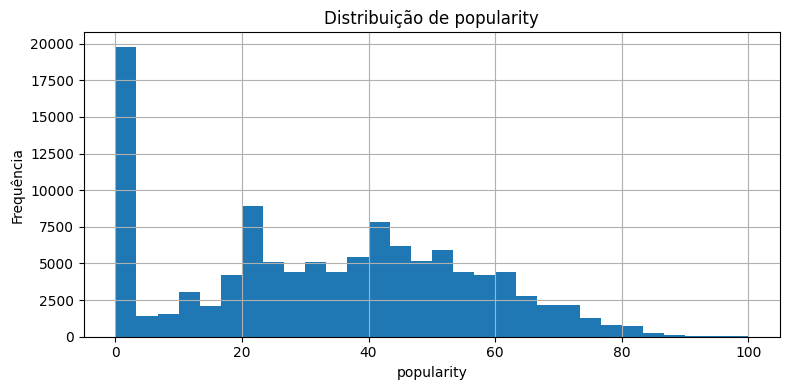

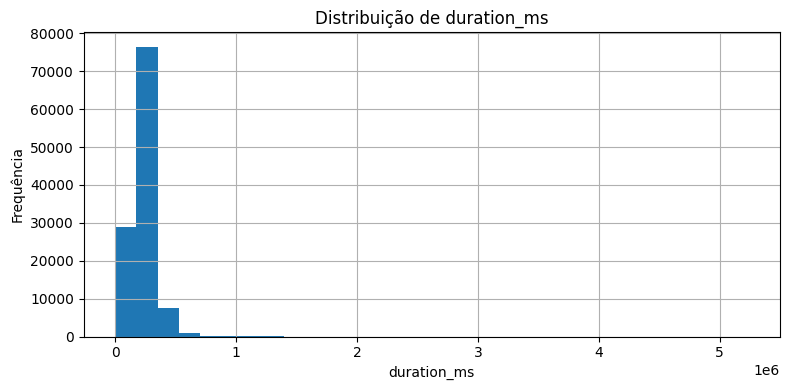

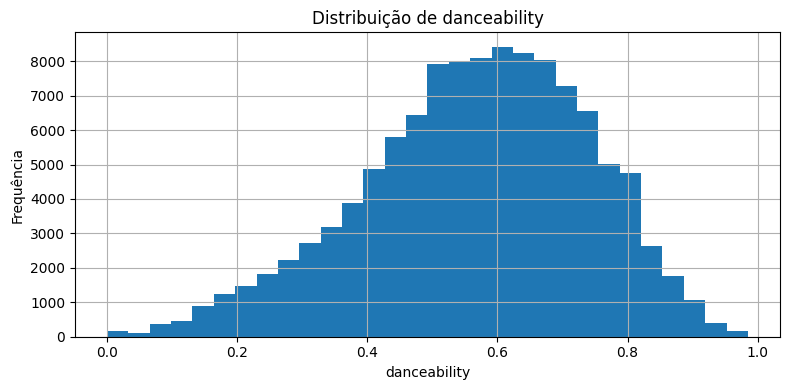

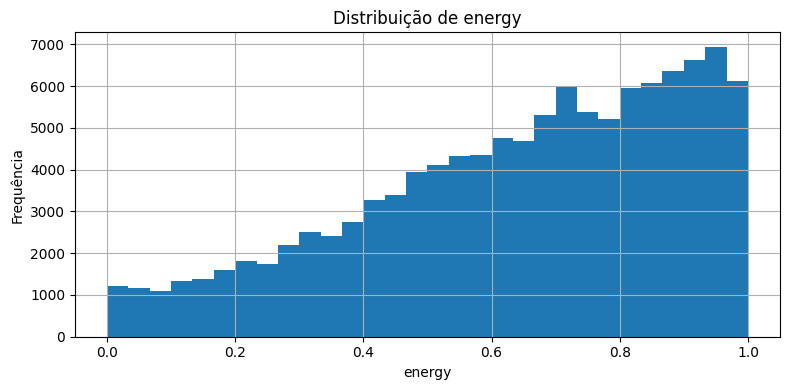

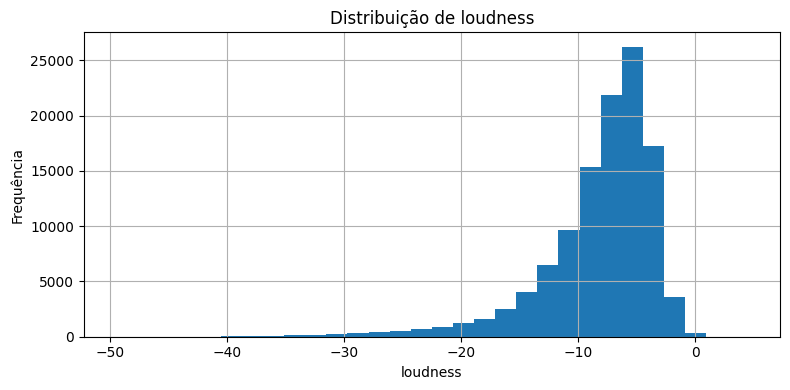

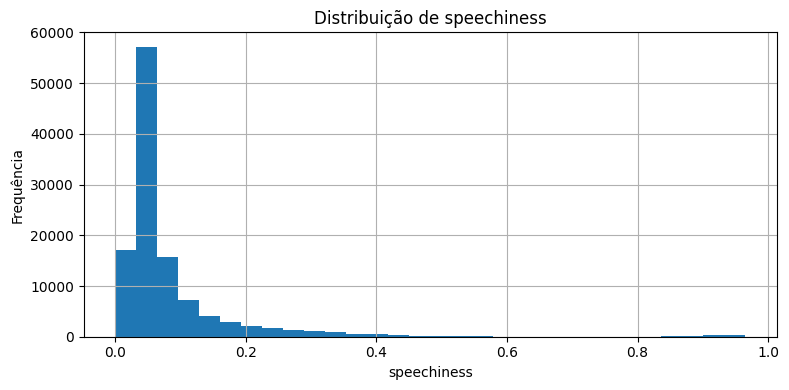

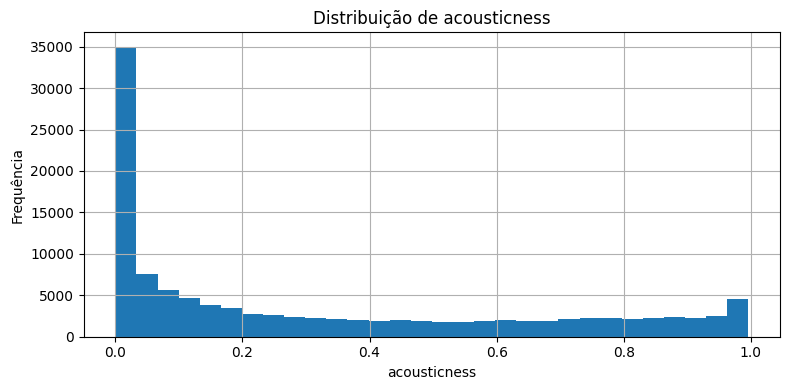

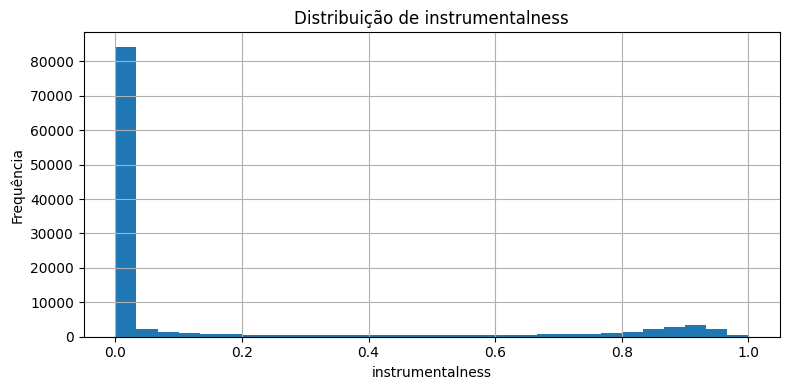

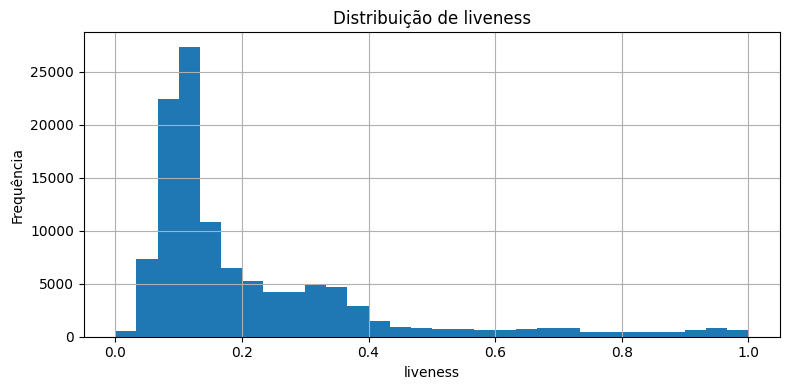

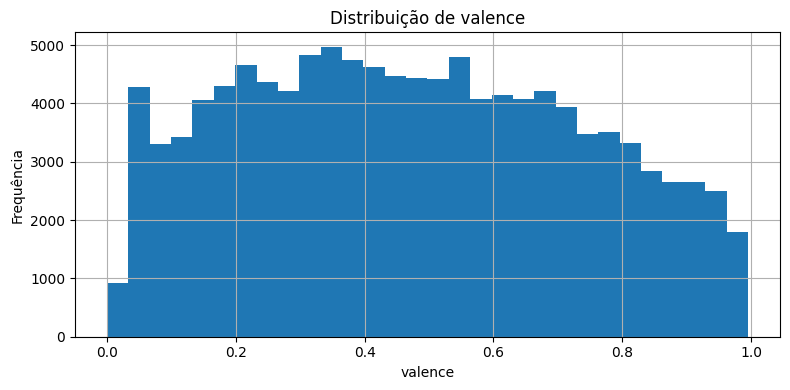

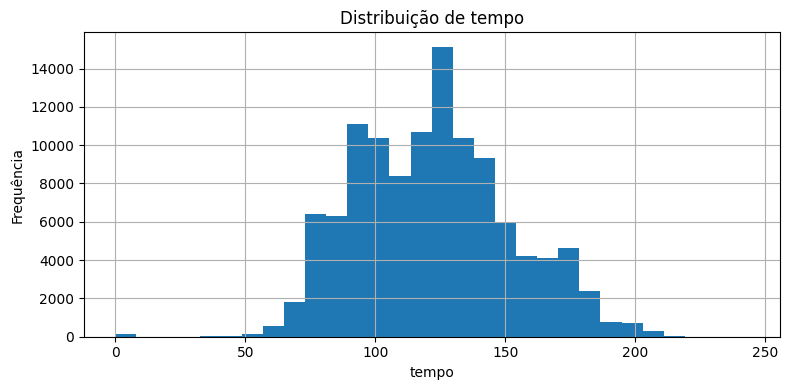

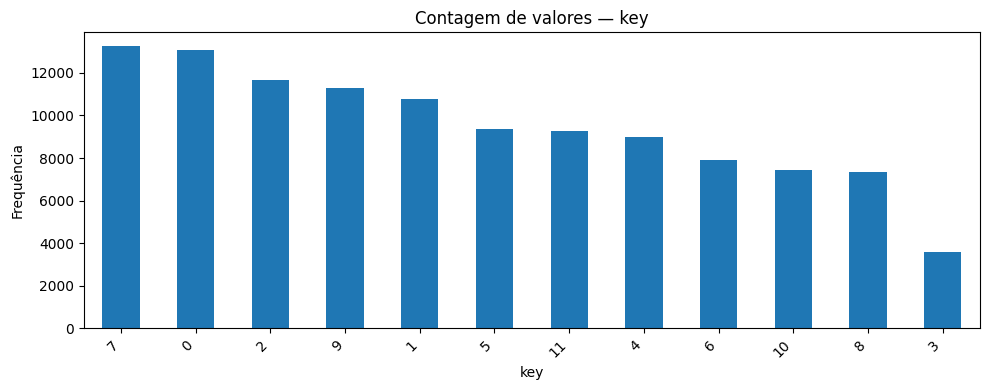

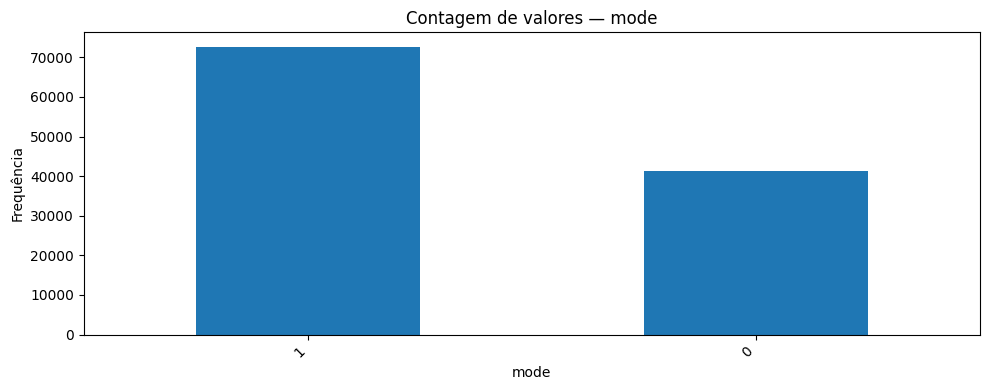

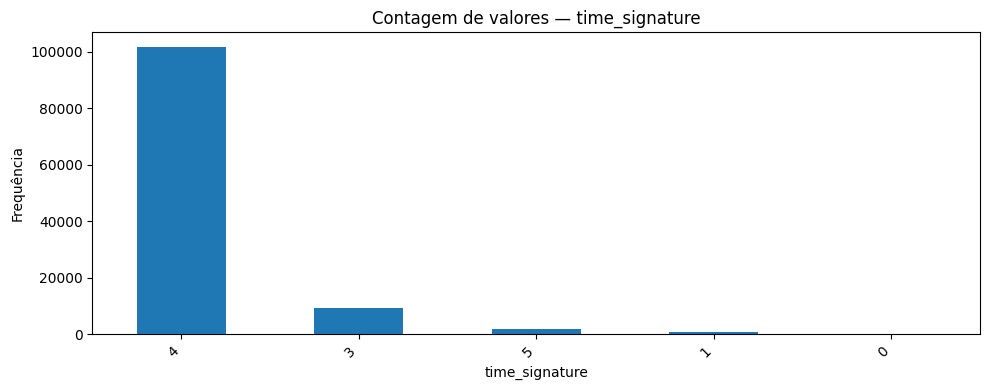

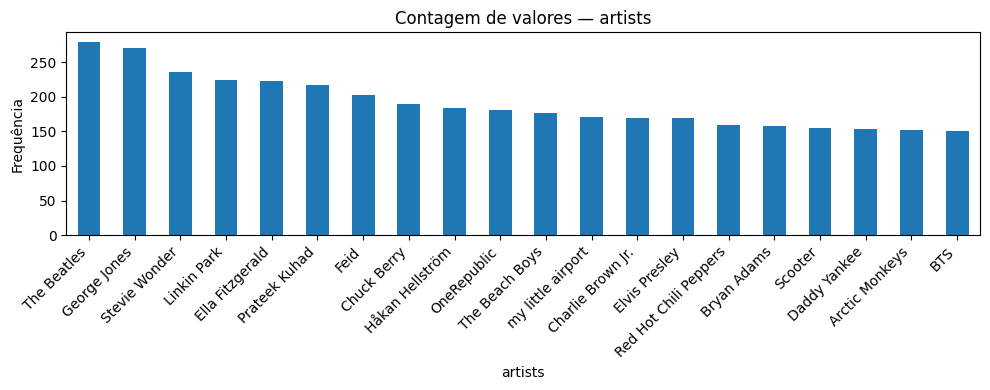

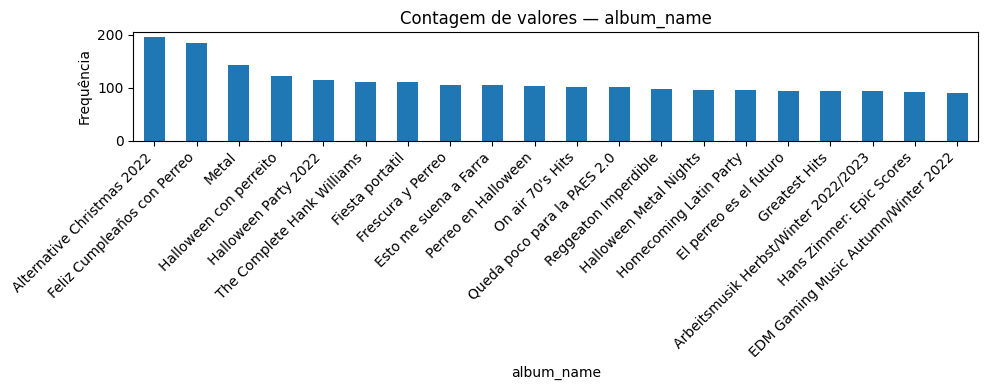

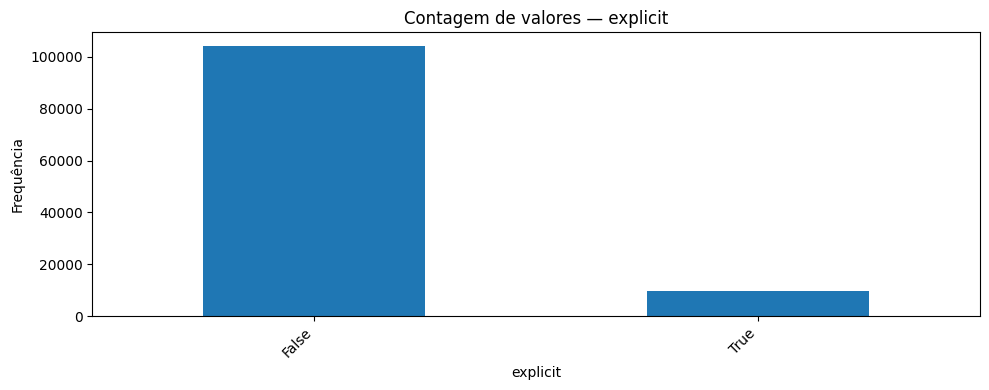

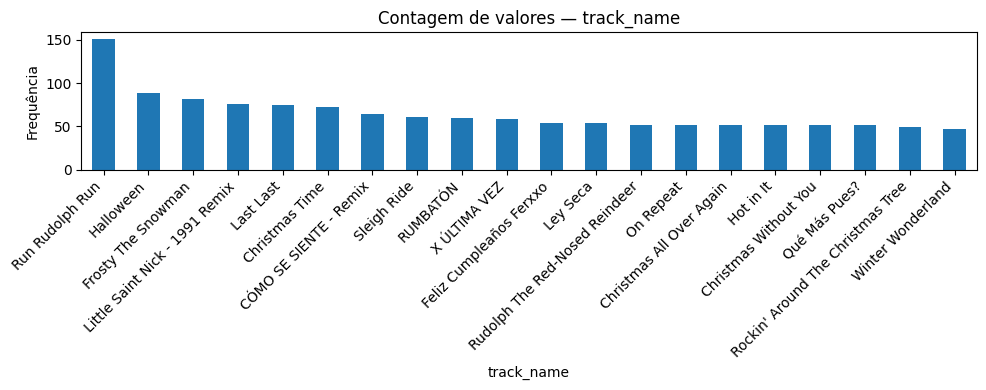

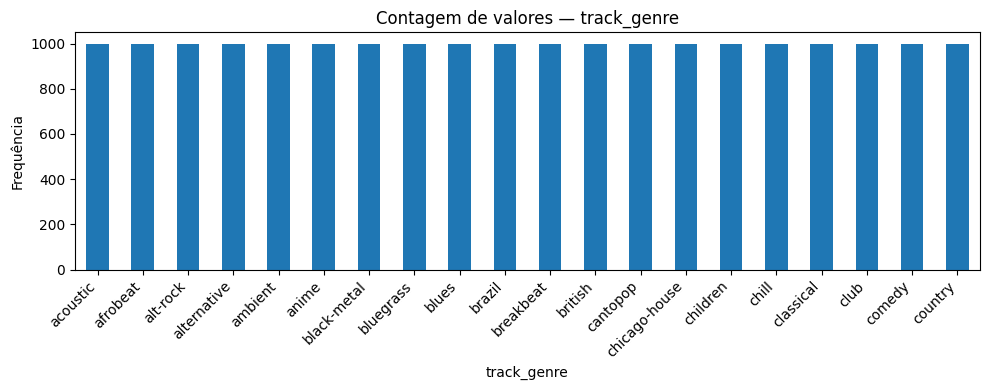

In [7]:
colunas_n = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
colunas_c = ['key','mode','time_signature','artists', 'album_name', 'explicit','track_name', 'track_genre']
for col in colunas_n:
    plot_distribuicao_numerica(df, col)
for col in colunas_c:
    plot_contagem_categorica(df, col)


## 2.2 Análise visual — interpretação

A interpretação deve evitar apenas descrever o óbvio. Procure responder:

- Há concentração de valores?

Sim. Um exemplo é a variável Speechiness

- Há valores extremos?

Sim. Duration_ms é um exemplo onde há valores de 10^6

- Há categorias muito raras?

Sim. time_signature == (0 ou 1) são bem raros.

- Há desbalanceamento?

Sim. time_signature é uma classe bem desbalanceada.

- Os padrões observados afetam a tarefa de mineração?

Sim. Alguns desses padrões demonstram que algumas features podem não ser tão úteis. Contudo, isso não indica que o trabalho é impossível ou muito difícil, para uma conclusão desse tipo, será necessário continuar o trabalho. Além disso, esses padrões também nos levam a querer realizar algumas modificações no dataset, como terminar de z-normalizar os dados numéricos e remover outliers (em duration, por exemplo).

- Alguma visualização sugere risco associado às diretrizes escolhidas?

Não. Apenas sugere que a tarefa pode ser "mais difícil", mas não algo específico contra as diretrizes.

> Não invente conclusões. Toda afirmação empírica deve estar apoiada em uma tabela, gráfico ou cálculo executado no notebook.


In [8]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
outliers = detectar_outliers_iqr(df, "duration_ms")
display(outliers.head())


Coluna: duration_ms
Q1: 174066.0
Q3: 261506.0
IQR: 87440.0
Limite inferior: 42906.0
Limite superior: 392666.0
Número de outliers: 5617


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
253,253,0I0l2Oo5zjpCEphpDJL0Pm,Motohiro Hata,言ノ葉,Rain - Long Ver.,44,447306,False,0.588,0.6040,...,-7.602,1,0.0240,0.3430,0.000069,0.2520,0.351,92.020,4,acoustic
650,650,6ad7bQ48TlqAgebCExUJVe,Ichiko Aoba,0,いきのこり●ぼくら,52,406103,False,0.592,0.0833,...,-16.517,0,0.0835,0.9460,0.079100,0.0941,0.205,143.243,4,acoustic
752,752,1TRIYxcVJYPki5AX2hZzZT,Luther Allison,Bad News Is Coming,Bad News Is Coming,52,445533,False,0.639,0.4960,...,-6.844,0,0.0375,0.7130,0.254000,0.0545,0.467,140.394,3,acoustic
851,851,5fomS2mZjvxxJ2iVH3fosc,John Elliott,All Too Well (Jake's Version),All Too Well - Jake's Version,33,578064,False,0.685,0.4830,...,-9.082,1,0.0253,0.0772,0.000061,0.1130,0.331,93.032,4,acoustic
896,896,0xOIqJadsikka2so1zhghO,Harley Poe,Horrorful,Alone in the Dark Mansion of Madness,26,403911,True,0.335,0.6960,...,-9.472,0,0.0307,0.6420,0.000000,0.1200,0.403,95.240,4,acoustic


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em [COLUNA] | Não se aplica | Não se aplica | Não se aplica |
| Duplicatas | tamanho do dataset > quantidade de track_id distintos | Remover| Às vezes, a música aparece 2x quando ela tem 2 ou mais gêneros musicais em que ela se encaixa. Deixamos apenas 1 por música. |
| Outliers em duration_ms | Visualmente notório | Remover outliers | Ruidos brancos, jingles de 10-15 segundos e coisas assim são prejudiciais e não nos fornecem dados úteis. |
| Categorias raras | Gráfico de visualização de "time_signature" | Ignorar | O desbalanceamento pode ser útil para o modelo. Além disso, tentar removê-lo implicaria em undersampling (remover dados) ou oversampling (criar dados). Contudo, ambas possibilidades trazem novos problemas que, possivelmente, são mais difíceis de tratar. |
| Atributos sensíveis ou identificadores | o atribuito chama "ID" | remover | Ele já não seria útil por ser string de qualquer jeito |

### Observação sobre responsabilidade

A remoção de duplicatas faz com que músicas que possuam mais de 1 gênero, ou seja, façam parte da intersessão de 2 grupos distintos, passem a pertencer a apenas um único gênero. Dessa forma, perde-se informação útil no dataset em nome da funcionalidade prática do algoritmo. Outras remoções podem dificultar ligeiramente a explicabilidade, mas não deve ser significativo.

Exemplo:

> A remoção de um atributo sensível pode reduzir risco de exposição indevida, mas também pode dificultar a análise de disparidades entre grupos. Essa decisão deve ser justificada com cuidado.


In [9]:
# Exemplo de preparação dos dados
# Esta célula é propositalmente genérica.
# O grupo deve adaptar de acordo com o dataset e a tarefa.

def preparar_dados_basico(
    df: pd.DataFrame,
    colunas_remover=None,
    imputar_numericas=True,
    imputar_categoricas=True
) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas explicitamente marcadas como irrelevantes ou identificadoras
    if colunas_remover is None:
        colunas_remover = [
            "track_id",
            "Unnamed: 0",
            "album_name"
        ]

    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    # 3. Exemplo de tratamento simples de nulos
    # Atenção: imputação deve ser justificada no texto.
    if imputar_numericas:
        for col in df_prep.select_dtypes(include=np.number).columns:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    if imputar_categoricas:
        for col in df_prep.select_dtypes(include=["object", "category"]).columns:
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_basico(df, colunas_remover=["track_id",
            "artists",
            "album_name",
            "popularity",
            "track_name",
            "track_genre",
            "Unnamed: 0"
            ])
display(df_prep.head())


,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4


#### One-Hot Encoding

In [10]:
def one_hot_encode_key_mode_time_signature(
    df: pd.DataFrame,
    drop_original: bool = True,
    prefix_sep: str = "_"
) -> pd.DataFrame:
    """
    One-hot encodes the categorical columns 'key', 'mode' and 'time_signature'.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    drop_original : bool, default True
        If True, remove the original categorical columns after encoding.
    prefix_sep : str, default "_"
        Separator used between column name and category value.

    Returns
    -------
    pd.DataFrame
        DataFrame with one-hot encoded features.
    """
    cols = ["key", "mode", "time_signature"]
    missing = [col for col in cols if col not in df.columns]
    if missing:
        raise KeyError(f"Colunas não encontradas para one-hot encoding: {missing}")

    df_encoded = pd.get_dummies(
        df,
        columns=cols,
        prefix=cols,
        prefix_sep=prefix_sep,
        dummy_na=False
    )

    if not drop_original:
        # get_dummies already drops originals, so restore them if necessary
        df_encoded = df_encoded.join(df[cols])

    return df_encoded

# Eu ainda não testei essa função, mas o exemplo de uso é esse aqui:
df_prep = one_hot_encode_key_mode_time_signature(df_prep)
display(df_prep.head())

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,230666,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,...,False,False,False,True,False,False,False,False,True,False
1,149610,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,...,False,False,False,False,True,False,False,False,True,False
2,210826,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,...,False,False,False,False,True,False,False,False,True,False
3,201933,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,...,False,False,False,False,True,False,False,True,False,False
4,198853,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,...,False,False,False,False,True,False,False,False,True,False


#### False/True -> 0/1

In [11]:
def bools_para_float(df: pd.DataFrame, inplace: bool = False) -> pd.DataFrame:
    """
    Converte colunas booleanas de um DataFrame em float, usando 0.0 para False e 1.0 para True.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    inplace : bool, default False
        Se True, modifica o DataFrame original; caso contrário, retorna uma cópia.

    Returns
    -------
    pd.DataFrame
        DataFrame com colunas booleanas convertidas para float.
    """
    df_out = df if inplace else df.copy()
    bool_cols = df_out.select_dtypes(include="bool").columns

    if len(bool_cols) > 0:
        df_out[bool_cols] = df_out[bool_cols].astype(float)

    return df_out

# Exemplo de uso:
df_prep = bools_para_float(df_prep)
display(df_prep.head())

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,230666,0.0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,149610,0.0,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,210826,0.0,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,201933,0.0,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,198853,0.0,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### Z-normalização de tudo

In [12]:
def z_normalizar_df(df: pd.DataFrame, colunas_incluir=None) -> pd.DataFrame:
    """
    Z-normaliza as colunas numéricas de um DataFrame.
    Se colunas_incluir for None, normaliza todas as colunas numéricas.
    Retorna uma cópia do DataFrame com as colunas selecionadas padronizadas.
    """
    df_norm = df.copy()

    if colunas_incluir is None:
        colunas_incluir = df_norm.select_dtypes(include=np.number).columns.tolist()

    colunas_incluir = [col for col in colunas_incluir if col in df_norm.columns]

    if len(colunas_incluir) == 0:
        return df_norm

    medias = df_norm[colunas_incluir].mean()
    desvios = df_norm[colunas_incluir].std(ddof=0).replace(0, 1)

    df_norm[colunas_incluir] = (df_norm[colunas_incluir] - medias) / desvios

    return df_norm

# Exemplo de uso:
df_prep_norm = z_normalizar_df(df_prep)
display(df_prep_norm.head())

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_9,key_10,key_11,mode_0,mode_1,time_signature_0,time_signature_1,time_signature_3,time_signature_4,time_signature_5
0,0.024575,-0.305767,0.629244,-0.717148,0.300828,0.551848,-0.850202,-0.504109,0.758743,0.929306,...,-0.331918,-0.264538,-0.297721,1.326281,-1.326281,-0.03784,-0.092782,-0.296200,0.345500,-0.127586
1,-0.730859,-0.305767,-0.845908,-1.889980,-1.784744,-0.078993,1.831732,-0.504094,-0.591211,-0.798690,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,-0.296200,0.345500,-0.127586
2,-0.160332,-0.305767,-0.742186,-1.122669,-0.293288,-0.273826,-0.315499,-0.504112,-0.507167,-1.365688,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,-0.296200,0.345500,-0.127586
3,-0.243214,-0.305767,-1.733304,-2.312994,-2.039252,-0.457309,1.774593,-0.503883,-0.428376,-1.276974,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,3.376099,-2.894359,-0.127586
4,-0.271919,-0.305767,0.295030,-0.788711,-0.282750,-0.303145,0.463399,-0.504112,-0.686285,-1.184403,...,-0.331918,-0.264538,-0.297721,-0.753988,0.753988,-0.03784,-0.092782,-0.296200,0.345500,-0.127586


## 2.4 Justificativa da preparação dos dados
Explique:

- quais colunas foram removidas e por quê;
Todas as colunas com string foram removidas porque elas não servem para os algoritmos de agrupamento.

- como valores ausentes foram tratados;

Não há valores ausentes.

- como variáveis categóricas foram tratadas;

Variáveis categóricas foram mantidas, desde que não fossem string.

- se houve normalização, discretização ou codificação;

Houve z-normalização das colunas numéricas.

- se houve remoção de outliers;

Houve remoção de outliers em duration_ms.

- quais riscos essas decisões introduzem;

Risco de perda de informação, mas não é significativo.

- como essas decisões se relacionam às diretrizes escolhidas.

As remoções feitas implicam em menos informações para gerar os grupos, o que implica em menos informações para explicar os grupos gerados, o que implica em menor explicabilidade. Contudo, acreditamos que, com as informações que sobraram, ainda é possível haver boa explicabilidade.

> A preparação dos dados não deve ser apenas uma sequência de comandos. Toda decisão relevante precisa de justificativa técnica.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** Propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro 

**Data de acesso:** 17/05/2026

**Link da conversa:** https://gemini.google.com/share/3a350162bbfa

#### Prompt principal — baseline

```text
Tenho um dataset com as seguintes colunas: 'Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre'.

A tarefa de mineração é agrupamento.
Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.
```

#### Síntese da resposta da LLM

Para o Data Understanding:

- visualizar histograma das variáveis numéricas para tentar entender a distribuição delas;
- analisar a escala das variáveis numericas, visto que a disparidade de escala pode ser um problema grande na hora de tentar rodar um algoritmo de agrupamento;
- gerar uma matriz de correlação para avaliar colinearidades;
- gerar boxplots para analisar outliers.

Para o Data Preparation:

- Descartar Unnamed;
- Remover duplicatas com mesmo track_id;
- Remover as colunas em formato string pois "os algoritmos de clusterização normalmente não lidam com texto";
- Salvar "track_genre" em uma outra tabela, antes de remover, pois isso será útil para avaliar os resultados;
- Converter duration_ms para minutos para facilitar interpretabilidade;
- Converter key, mode e time_signature para One-Hot Encoding ou remover todas elas;

- Fazer uma z-normalização dos dados com Standard Scaler
- Sugeriu fazer redução de dimensionalidade (colocou como opcional), mas não mencionou diretamente como fazê-lo.


---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro 

**Data de acesso:** 17/05/2026 

**Link da conversa:** https://gemini.google.com/share/1797e0a9b2ad 

#### Prompt principal — guiado

```text
Tenho um dataset com as seguintes colunas: 'Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre'.

A tarefa de mineração é agrupamento.
Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.

Considere explicitamente as seguintes diretrizes de IA responsável na sua formulação:

1. Monitoramento e Avaliação: Como não existe uma resposta correta prévia em problemas de clusterização não supervisionados, avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas (como Silhouette Score) e propondo comparações entre algoritmos.

2. Explicabilidade: A clusterização pode gerar agrupamentos difíceis de interpretar. Portanto, justifique os parâmetros e exija descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, para que façam sentido como perfis musicais reais.

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis, se houver;
- riscos de viés ou perda de informação;
- decisões que devem ser documentadas;
- transformações necessárias;
- limitações e trade-offs.
```

#### Síntese da resposta da LLM

Para Data Understanding:

Ele fez uma análise um pouco mais detalhada de cada variável, analisando e "pré-sugerindo" / justificando o que fazer com elas

- remover Unnamed;
- descartar identificadores (track_id, artists, album_name, track_name), mas reter em uma tabela para análise futura;
- padronizar as ordens de grandeza: duration_ms, loudness, tempo
- Fazer One-Hot Ecoding para key, mode, time_signature, track_genre, explicit (avisou que track_genre pode enviesar o modelo se for para agrupar por gênero musical)
- Falou que popularidade pode ofuscar a similaridade sonora agrupando apenas "hits" vs "fracassos comerciais", mas não deixou claro o que fazer com essa informação [nesta parte da resposta].

Para Data Preparation:

O modelo foi dando instruções diretas e explicando-as rapidamente:

- Remover track_genre e popularity;
- Considerar track_genre e artist como atributos sensíveis;
- z-normalização em todas as variáveis;
- Mencionou reduzir a dimensionalidade, mas também falou do trade-off da redução da dimensionalidade com a perda da explicabilidade. Sugeriu não reduzir por enquanto.
- Ficar atendo a outliers em duration e removê-los.

Além disso, o modelo fez uma série de sugestões para seguir as diretrizes:

- Usar Silhouette Score e Davies-Bouldin Index como métricas quantitativas de avaliação;
- Comparar resultados do K-Means, Clusterização Hierárquica e DBSCAN
- Fazer uma "auditoria semântica" após o algoritmo rodar e a solução só será validada se fizer sentido com os dados reais.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Não se aplica | Não se aplica | Não se aplica |
| Tratamento de outliers | Remover outliers em duration_ms | Remover outliers em duration_ms | [ACEITAR] |
| Atributos sensíveis | Remover (mas não mencionou que são sensíveis, eles estavam inclusos no grupo dos atributos em "string") | Remover (mencionou que são sensíveis) | [ACEITAR] |
| Codificação de variáveis | One-Hot Encoding para key (tom), mode (maior/menor) e time_signature | One-Hot Encoding para key, mode, time_signature, track_genre, explicit | Fazer One-Hot Encoding nas variáveis numéricas não-categóricas |
| Redução de dimensionalidade | Mencinou e sugeriu fazer | Mencionou e também falou de tradeoff com explicabilidade | REJEITAR |
| Justificativa técnica | Todas as decisões técnicas foram acompanhadas de justificativa técnica plausível. Além disso, o modelo tomou a frente em algumas decisões.| Em geral, ele nos deu um embasamento técnico, nos disse qual decisão tomar mas deixando claro os Trade-offs | Trilha B foi um pouco melhor|
| Riscos e limitações | Não mencionou limitações e tradeoffs | Mencionou tradoffs várias vezes, embora tenha sugerido as mesmas estratégias em quase todas as situações | Trilha B foi um pouco melhor|

### Análise crítica

Neste caso, ambos os modelos foram excelentes. Mesmo o modelo baseline teve preocupação com interpretabilidade.
É válido lembrar que, como estou com minha conta pessoal do Gemini, ele pode ter "aprendido" essa preocupação após o TP1.
Algumas sugestões corretas: z-normalização e remoção de outliers.
Nada estava incompleto ou tecnicamente errado. Contudo, é válido mencionar que a trilha B sugeriu comparar diversos métodos de clusterização, o que pode fazer sentido para a diretriz de monitoramento e avaliação, mas que pode chegar a ser inviável pelo tamanho do dataset.
Foram aceitas as sugestões citadas como corretas.
Foi rejeitada a sugestão de converter duration para minutos.
Nesta sessão, corrigimos as variáveis sugeridas para One-Hot Encoding.


A análise deve deixar claro:

- o que a LLM sugeriu corretamente;
- o que estava incompleto;
- o que estava tecnicamente errado;
- o que foi aceito;
- o que foi rejeitado;
- o que foi corrigido pelo grupo.


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de agrupamento, a modelagem pode envolver, por exemplo:

- K-Means;
- Hierarchical Clustering;
- DBSCAN.
- Gaussian Mixture Models
- Métricas de avaliação dos clusterings


O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** Propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro

**Data de acesso:** 17/05/2026 

**Link da conversa:** https://gemini.google.com/share/3a350162bbfa

#### Prompt principal — baseline

```text
Com base no dataset Spotify Tracks Dataset e na tarefa de agrupamento, proponha uma estratégia de modelagem.
Indique algoritmos, parâmetros iniciais, métricas de avaliação e como comparar resultados.

```

#### Síntese da resposta da LLM

A estratégia propõe testar três algoritmos de agrupamento no Spotify Tracks Dataset:

- K-Means: usado como baseline por ser rápido e eficiente em grandes bases. O número de clusters ($k$) pode ser definido pelo Método do Cotovelo.
- DBSCAN: identifica grupos por densidade e consegue detectar outliers, sem precisar definir previamente o número de clusters.
- Gaussian Mixture Models (GMM): permite agrupamento probabilístico, útil porque músicas podem pertencer parcialmente a mais de um estilo.

Para avaliar os modelos, recomenda-se usar métricas internas como:

- Silhouette Score (quanto maior, melhor);
- Davies-Bouldin Index (quanto menor, melhor);
- Calinski-Harabasz Index (quanto maior, melhor).

A comparação dos resultados deve combinar análise quantitativa e interpretação prática. Após escolher o melhor modelo, é possível analisar as médias das características acústicas de cada cluster para identificar perfis musicais, como músicas animadas, relaxantes ou faladas. Também é interessante comparar os clusters com a coluna de gêneros originais (track_genre) para verificar se o modelo conseguiu redescobrir padrões musicais coerentes.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro

**Data de acesso:** 17/05/2026

**Link da conversa:** https://gemini.google.com/share/1797e0a9b2ad 

#### Prompt principal — guiado

```text
Com base no dataset Spotify Tracks Database e na tarefa de agrupamento, proponha uma estratégia de modelagem.

Considere explicitamente as diretrizes:
1. Monitoramento e Avaliação: Como não existe uma resposta correta prévia em problemas de clusterização não supervisionados, avalie a qualidade dos agrupamentos de forma criteriosa, sugerindo e justificando métricas quantitativas (como Silhouette Score) e propondo comparações entre algoritmos.

2. Explicabilidade: A clusterização pode gerar agrupamentos difíceis de interpretar. Portanto, justifique os parâmetros e exija descrições semânticas claras para cada cluster, baseando-se nas características acústicas predominantes, para que façam sentido como perfis musicais reais.

Na resposta, indique:
- algoritmos adequados;
- parâmetros iniciais;
- métricas de avaliação;
- riscos metodológicos;
- impacto das diretrizes nas escolhas;
- trade-offs entre desempenho, interpretabilidade, custo computacional e qualidade da solução.

```

#### Síntese da resposta da LLM

Na etapa de modelagem, são sugeridos três algoritmos principais:

- K-Means: rápido e interpretável;
- DBSCAN: identifica clusters por densidade e detecta outliers;
- Clusterização Hierárquica: permite visualizar relações entre grupos via dendrogramas.

A avaliação dos agrupamentos deve usar métricas como:

- Silhouette Score;
- Davies-Bouldin Index;
- Calinski-Harabasz Index.

Além da avaliação matemática, a solução deve priorizar explicabilidade. Cada cluster precisa receber uma interpretação semântica baseada nas características predominantes, como:

- músicas festivas e energéticas;
- músicas acústicas e relaxantes;
- músicas instrumentais ou focadas em fala.

A LLM também destaca riscos metodológicos, como:

- viés causado pela popularidade;
- perda de significado em espaços de alta dimensionalidade;
- limitações dos algoritmos em representar corretamente a diversidade musical.

## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | K-Means, DBSCAN e GMM | K-Means, DBSCAN e Clusterização Hierárquica | SIM | A Trilha A priorizou modelos probabilísticos (GMM), enquanto a Trilha B substituiu o GMM pela abordagem hierárquica, focando mais em interpretabilidade visual via dendrogramas. |
| Parâmetros sugeridos | Método do Cotovelo para k, eps, min_samples, AIC/BIC, covariance_type='full' | Intervalo k∈[4,15], k-means++, eps, min_samples=2×D, linkage='ward'| SIM | A Trilha B apresentou parâmetros mais operacionalizáveis e diretamente aplicáveis, enquanto a Trilha A trouxe parâmetros mais avançados para modelagem probabilística. |
| Métricas sugeridas | Silhouette Score, Davies-Bouldin e Calinski-Harabasz | Silhouette Score, Davies-Bouldin e Calinski-Harabasz | NÃO | As duas trilhas convergiram nas mesmas métricas de avaliação interna, reforçando boas práticas para validação em clusterização não supervisionada. |
| Preparação exigida | Normalização, seleção de atributos, possível PCA, separação entre treino e metadados | Padronização Z-score, remoção de identificadores, retenção de metadados auxiliares, possível PCA apenas para visualização | SIM | A Trilha B detalhou mais explicitamente o pipeline de preparação e os riscos associados. |
| Interpretabilidade | Perfis semânticos dos clusters e validação com track_genre | Perfis semânticos, auditoria manual de músicas e interpretação dos centroides | SIM | A Trilha B aprofundou a explicabilidade ao exigir auditoria humana e análise semântica detalhada dos clusters. |
| Custo computacional | Destacou MiniBatchKMeans para grandes volumes | Discutiu complexidade O(n³) da clusterização hierárquica e trade-offs computacionais | SIM | A Trilha A focou em escalabilidade prática; a Trilha B analisou explicitamente o impacto computacional das escolhas metodológicas. |
| Riscos ou limitações | Sobreposição entre gêneros, sensibilidade a formatos de cluster, ruído | Maldição da dimensionalidade, viés do K-Means, sensibilidade do DBSCAN, perda de interpretabilidade | SIM | A Trilha B apresentou análise metodológica mais ampla e detalhada sobre limitações estatísticas e geométricas |
| Aderência às diretrizes | Aplicou avaliação quantitativa e interpretação semântica | Aplicou avaliação quantitativa, interpretabilidade e justificativa metodológica explícita | SIM | Ambas seguiram as diretrizes de IA responsável, mas a Trilha B integrou essas exigências de forma mais explícita ao processo decisório. |

### Síntese

As duas trilhas apresentaram estratégias coerentes para clusterização do Spotify Tracks Dataset, convergindo em diversos pontos fundamentais, como o uso de métricas internas (Silhouette Score, Davies-Bouldin e Calinski-Harabasz), necessidade de padronização dos dados e preocupação com interpretabilidade dos agrupamentos.

A principal diferença foi o nível de aprofundamento metodológico. A Trilha A apresentou uma abordagem mais orientada à modelagem prática e escalável, incluindo algoritmos probabilísticos como GMM e soluções computacionalmente eficientes, como MiniBatchKMeans. Já a Trilha B estruturou o processo de forma mais analítica e alinhada às diretrizes de IA responsável, detalhando riscos metodológicos, justificativas de parâmetros, impactos computacionais e limitações geométricas dos algoritmos.

Além disso, a Trilha B enfatizou mais fortemente a explicabilidade dos resultados, propondo auditoria humana dos clusters e interpretação semântica baseada em centroides revertidos à escala original. Isso tornou a solução mais transparente e adequada para análise crítica dos agrupamentos musicais.

Em termos práticos, a Trilha A favorece desempenho e flexibilidade de modelagem, enquanto a Trilha B prioriza interpretabilidade, justificativa metodológica e rastreabilidade das decisões analíticas.


## 3.4 Template de modelagem para agrupamento

Use esta subseção se o TP atual envolver agrupamento. Caso contrário, remova ou deixe claro que ela não foi utilizada.

> **Atenção:** em agrupamento, não há rótulo verdadeiro na maioria dos casos. A avaliação deve combinar métricas internas, análise visual quando possível e interpretação substantiva dos grupos.

Nosso grupo optou por testar quatro algoritmos de agrupamento, incorporando sugestões tanto da LLM da Trilha A quanto da LLM da Trilha B:

- K-Means

- DBSCAN

- Gaussian Mixture Model (GMM)

- Clustering Hierárquico


## K-Means

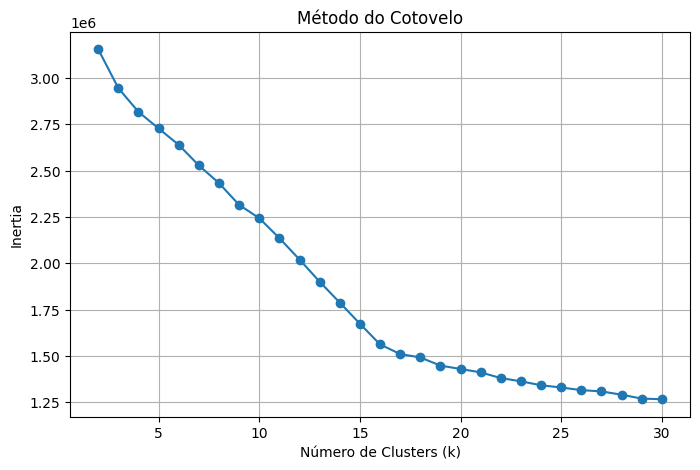

[3155501.831209744,
 2945365.2864235193,
 2817255.8018773375,
 2727814.5455233757,
 2639111.4838358555,
 2528113.38395688,
 2432741.300703458,
 2315080.533139907,
 2243545.8112884806,
 2135539.586281715,
 2020056.995337941,
 1900483.9815722827,
 1787688.9834775517,
 1673604.4875336394,
 1561908.4929058962,
 1509926.1518923834,
 1491518.0606951374,
 1447443.5726388874,
 1429271.5146011075,
 1410884.8889824236,
 1380164.0711030753,
 1362707.9966275583,
 1341294.7393558428,
 1329274.858886344,
 1315031.2152276656,
 1308215.5358204287,
 1290264.2808658746,
 1269378.5652264247,
 1265987.3346179416]

In [13]:
# ============================================================
# Clusterização com K-Means + Método do Cotovelo
# Dataset já está normalizado e com One-Hot Encoding
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42

# ============================================================
# MÉTODO DO COTOVELO
# ============================================================

def metodo_cotovelo(
    X,
    k_min=2,
    k_max=30,
    random_state=RANDOM_STATE
):
    """
    Calcula a inertia para diferentes valores de k.
    """

    inertias = []
    valores_k = range(k_min, k_max + 1)

    for k in valores_k:

        modelo = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=random_state
        )

        modelo.fit(X)

        inertias.append(modelo.inertia_)

    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        valores_k,
        inertias,
        marker="o"
    )

    plt.xlabel("Número de Clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Método do Cotovelo")
    plt.grid(True)

    plt.show()

    return inertias


# ============================================================
# EXECUÇÃO DO MÉTODO DO COTOVELO
# ============================================================

metodo_cotovelo(
    X=df_prep_norm,
    k_min=2,
    k_max=30
)

In [14]:
# ============================================================
# ESCOLHA DO k
# Após observar o gráfico, escolhemos o melhor valor
# ============================================================

k_escolhido = 16

# ============================================================
# EXECUÇÃO FINAL DO K-MEANS
# ============================================================

def executar_kmeans(
    X,
    n_clusters,
    random_state=RANDOM_STATE
):

    modelo = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=10,
        random_state=random_state
    )

    labels = modelo.fit_predict(X)

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "n_clusters": n_clusters,
        "silhouette_score": silhouette_score(X, labels),
        "davies_bouldin_score": davies_bouldin_score(X, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X, labels),
        "inertia": modelo.inertia_
    }

    return resultados


resultados_kmeans = executar_kmeans(
    X=df_prep_norm,
    n_clusters=k_escolhido
)

# ============================================================
# RESULTADOS
# ============================================================

print("=" * 50)
print("RESULTADOS K-Means")
print("=" * 50)


print(f"Número de clusters: {resultados_kmeans['n_clusters']}")
print(f"Silhouette Score: {resultados_kmeans['silhouette_score']:.4f}")
print(f"Davies-Bouldin Score: {resultados_kmeans['davies_bouldin_score']:.4f}")
print(f"Calinski-Harabasz Score: {resultados_kmeans['calinski_harabasz_score']:.2f}")
print(f"Inertia: {resultados_kmeans['inertia']:.2f}")

# ============================================================
# ADICIONA CLUSTERS AO DATAFRAME
# ============================================================

df["cluster_kmeans"] = resultados_kmeans["labels"]

RESULTADOS K-Means
Número de clusters: 16
Silhouette Score: 0.2917
Davies-Bouldin Score: 1.2462
Calinski-Harabasz Score: 9039.91
Inertia: 1561908.49


In [15]:
# ============================================================
# INSPEÇÃO DOS CLUSTERS
# ============================================================

cluster_exemplo = 0

print("\nExemplos de músicas do cluster 0 :\n")

print(
    df[df["cluster_kmeans"] == cluster_exemplo][
        ["track_name", "artists", "track_genre"]
    ].head(10)
)


Exemplos de músicas do cluster 0 :

                     track_name               artists track_genre
17                  At My Worst  Andrew Foy;Renee Foy    acoustic
38           This Time Tomorrow        Brandi Carlile    acoustic
41            When You're Wrong        Brandi Carlile    acoustic
80                  Heavy Heart       Gabrielle Aplin    acoustic
86                        Brave        Sara Bareilles    acoustic
89                 Heaven Knows     Five For Fighting    acoustic
101    Somebody Else - Acoustic       Callum J Wright    acoustic
121                     Mr Blue       Catherine Feeny    acoustic
126  Collide - Acoustic Version             Howie Day    acoustic
142  The Remedy (I Won't Worry)            Jason Mraz    acoustic


## DBSCAN

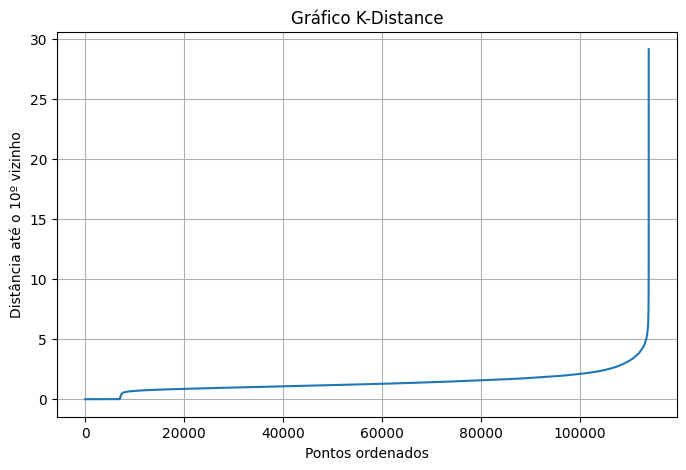

In [16]:
# ============================================================
# Clusterização com DBSCAN
# Dataset já normalizado e com One-Hot Encoding aplicado
# ============================================================

from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# FUNÇÃO PARA GERAR O GRÁFICO K-DISTANCE
# ============================================================

def plotar_k_distance(
    X,
    min_samples=10
):
    """
    Gera gráfico K-Distance para auxiliar na escolha do eps.
    """

    vizinhos = NearestNeighbors(
        n_neighbors=min_samples
    )

    vizinhos_fit = vizinhos.fit(X)

    distancias, indices = vizinhos_fit.kneighbors(X)

    # Última coluna = distância até o k-ésimo vizinho
    distancias = np.sort(distancias[:, -1])

    plt.figure(figsize=(8, 5))

    plt.plot(distancias)

    plt.title("Gráfico K-Distance")
    plt.xlabel("Pontos ordenados")
    plt.ylabel(f"Distância até o {min_samples}º vizinho")

    plt.grid(True)
    plt.show()

    return distancias

# ============================================================
# EXECUÇÃO DO K-DISTANCE
# ============================================================

# Regra comum:
# min_samples ≈ 2 × número de features

min_samples = 10

distancias = plotar_k_distance(
    X=df_prep_norm,
    min_samples=min_samples
)


In [17]:
# ============================================================
# ESCOLHA DO EPS
# ============================================================

# Após visualizar o gráfico,
# escolha o ponto da "curva acentuada"

eps_escolhido = 4

# ============================================================
# EXECUÇÃO DO DBSCAN
# ============================================================

def executar_dbscan(
    X,
    eps,
    min_samples
):
    """
    Executa DBSCAN e calcula métricas.
    """

    modelo = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean",
        n_jobs=-1
    )

    labels = modelo.fit_predict(X)

    # ========================================================
    # Número de clusters
    # Ignora ruído (-1)
    # ========================================================

    clusters_validos = set(labels)

    if -1 in clusters_validos:
        n_clusters = len(clusters_validos) - 1
    else:
        n_clusters = len(clusters_validos)

    # ========================================================
    # Quantidade de ruído
    # ========================================================

    n_ruido = list(labels).count(-1)

    # ========================================================
    # MÉTRICAS
    # Algumas métricas falham se houver apenas 1 cluster
    # ========================================================

    if n_clusters > 1:

        silhouette = silhouette_score(X, labels)

        davies = davies_bouldin_score(X, labels)

        calinski = calinski_harabasz_score(X, labels)

    else:

        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "n_clusters": n_clusters,
        "n_ruido": n_ruido,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies,
        "calinski_harabasz_score": calinski
    }

    return resultados


# ============================================================
# EXECUÇÃO FINAL
# ============================================================

resultados_dbscan = executar_dbscan(
    X=df_prep_norm,
    eps=eps_escolhido,
    min_samples=min_samples
)

# ============================================================
# RESULTADOS
# ============================================================

print("=" * 50)
print("RESULTADOS DBSCAN")
print("=" * 50)

print(f"Número de clusters: {resultados_dbscan['n_clusters']}")

print(f"Pontos classificados como ruído: "
      f"{resultados_dbscan['n_ruido']}")

print(f"Silhouette Score: "
      f"{resultados_dbscan['silhouette_score']:.4f}")

print(f"Davies-Bouldin Score: "
      f"{resultados_dbscan['davies_bouldin_score']:.4f}")

print(f"Calinski-Harabasz Score: "
      f"{resultados_dbscan['calinski_harabasz_score']:.2f}")

# ============================================================
# ADICIONA CLUSTERS AO DATAFRAME
# ============================================================

df["cluster_dbscan"] = resultados_dbscan["labels"]

# ============================================================
# DISTRIBUIÇÃO DOS CLUSTERS
# ============================================================

print("\nDistribuição dos clusters:\n")

print(
    df["cluster_dbscan"]
    .value_counts()
    .sort_index()
)

# ============================================================
# INSPEÇÃO DOS CLUSTERS
# ============================================================

# Cluster específico
cluster_exemplo = 0

print("\nExemplos de músicas do cluster 0:\n")

print(
    df[df["cluster_dbscan"] == cluster_exemplo][
        ["track_name", "artists", "track_genre"]
    ].head(10)
)

RESULTADOS DBSCAN
Número de clusters: 66
Pontos classificados como ruído: 672
Silhouette Score: 0.3028
Davies-Bouldin Score: 1.7986
Calinski-Harabasz Score: 2280.77

Distribuição dos clusters:

cluster_dbscan
-1       672
 0      9633
 1     11546
 2      1150
 3     10305
       ...  
 61       12
 62       25
 63       15
 64       15
 65       13
Name: count, Length: 67, dtype: int64

Exemplos de músicas do cluster 0:

                track_name                artists track_genre
0                   Comedy            Gen Hoshino    acoustic
1         Ghost - Acoustic           Ben Woodward    acoustic
9                   Hunger         Ross Copperman    acoustic
42  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
43  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
45  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
46  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
47  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
48  You and Me o

## Gaussian Mixture Model (GMM)

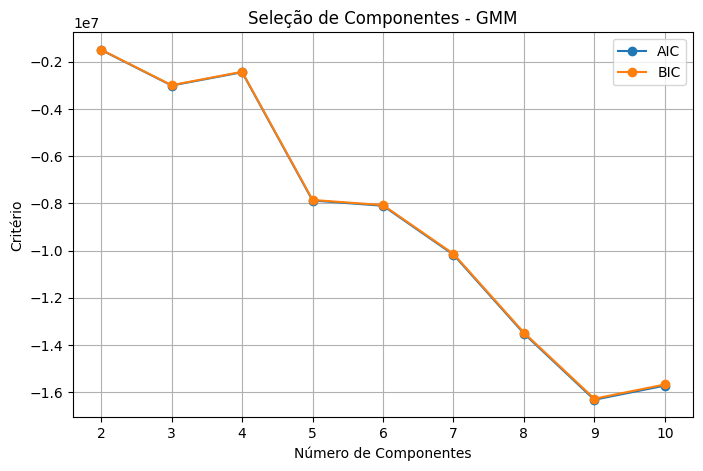

In [18]:
# ============================================================
# Gaussian Mixture Model (GMM)
# Dataset já normalizado e preparado
# ============================================================

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

RANDOM_STATE = 42

# ============================================================
# FUNÇÃO PARA TESTAR DIFERENTES NÚMEROS DE COMPONENTES
# Utiliza AIC e BIC
# ============================================================

def avaliar_gmm(
    X,
    n_components_range=range(2, 11),
    covariance_type="full"
):
    """
    Avalia diferentes números de componentes
    utilizando AIC e BIC.
    """

    aic_scores = []
    bic_scores = []

    for n in n_components_range:

        modelo = GaussianMixture(
            n_components=n,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE
        )

        modelo.fit(X)

        aic_scores.append(modelo.aic(X))
        bic_scores.append(modelo.bic(X))

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        list(n_components_range),
        aic_scores,
        marker="o",
        label="AIC"
    )

    plt.plot(
        list(n_components_range),
        bic_scores,
        marker="o",
        label="BIC"
    )

    plt.xlabel("Número de Componentes")
    plt.ylabel("Critério")
    plt.title("Seleção de Componentes - GMM")

    plt.legend()
    plt.grid(True)

    plt.show()

    return aic_scores, bic_scores


# ============================================================
# EXECUÇÃO DA AVALIAÇÃO
# ============================================================

aic_scores, bic_scores = avaliar_gmm(
    X=df_prep_norm,
    n_components_range=range(2, 11),
    covariance_type="full"
)

In [19]:
# ============================================================
# ESCOLHA DO NÚMERO DE COMPONENTES
# Escolhemos o ponto com menor BIC/AIC
# ============================================================

n_components_escolhido = 9


# ============================================================
# EXECUÇÃO DO GMM
# ============================================================

def executar_gmm(
    X,
    n_components,
    covariance_type="full"
):
    """
    Executa Gaussian Mixture Model.
    """

    modelo = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=RANDOM_STATE
    )

    modelo.fit(X)

    # ========================================================
    # LABELS
    # ========================================================

    labels = modelo.predict(X)

    # ========================================================
    # PROBABILIDADES
    # ========================================================

    probabilidades = modelo.predict_proba(X)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    silhouette = silhouette_score(X, labels)

    davies = davies_bouldin_score(X, labels)

    calinski = calinski_harabasz_score(X, labels)

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "probabilidades": probabilidades,
        "n_components": n_components,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies,
        "calinski_harabasz_score": calinski,
        "aic": modelo.aic(X),
        "bic": modelo.bic(X)
    }

    return resultados


# ============================================================
# EXECUÇÃO FINAL
# ============================================================

resultados_gmm = executar_gmm(
    X=df_prep_norm,
    n_components=n_components_escolhido,
    covariance_type="full"
)

# ============================================================
# RESULTADOS
# ============================================================

print("=" * 50)
print("RESULTADOS - GMM")
print("=" * 50)

print(f"Número de componentes: "
      f"{resultados_gmm['n_components']}")

print(f"Silhouette Score: "
      f"{resultados_gmm['silhouette_score']:.4f}")

print(f"Davies-Bouldin Score: "
      f"{resultados_gmm['davies_bouldin_score']:.4f}")

print(f"Calinski-Harabasz Score: "
      f"{resultados_gmm['calinski_harabasz_score']:.2f}")

print(f"AIC: {resultados_gmm['aic']:.2f}")

print(f"BIC: {resultados_gmm['bic']:.2f}")

# ============================================================
# ADICIONA CLUSTERS AO DATAFRAME
# ============================================================

df["cluster_gmm"] = resultados_gmm["labels"]

# ============================================================
# DISTRIBUIÇÃO DOS CLUSTERS
# ============================================================

print("\nDistribuição dos clusters:\n")

print(
    df["cluster_gmm"]
    .value_counts()
    .sort_index()
)

# ============================================================
# PROBABILIDADES DE PERTENCIMENTO
# ============================================================

probs = resultados_gmm["probabilidades"]

# Exemplo:
# probabilidade da primeira música pertencer a cada cluster

print("\nProbabilidades da primeira música:\n")

print(probs[0])

# ============================================================
# INSPEÇÃO DOS CLUSTERS
# ============================================================

cluster_exemplo = 0

print("\nExemplos de músicas do cluster 0:\n")

print(
    df[df["cluster_gmm"] == cluster_exemplo][
        ["track_name", "artists", "track_genre"]
    ].head(10)
)

RESULTADOS - GMM
Número de componentes: 9
Silhouette Score: 0.1720
Davies-Bouldin Score: 2.1288
Calinski-Harabasz Score: 6325.72
AIC: -16322633.12
BIC: -16279592.15

Distribuição dos clusters:

cluster_gmm
0     9642
1    10317
2    10895
3    25575
4     7367
5     9094
6     8002
7    21556
8    11552
Name: count, dtype: int64

Probabilidades da primeira música:

[1. 0. 0. 0. 0. 0. 0. 0. 0.]

Exemplos de músicas do cluster 0:

                track_name                artists track_genre
0                   Comedy            Gen Hoshino    acoustic
1         Ghost - Acoustic           Ben Woodward    acoustic
9                   Hunger         Ross Copperman    acoustic
42  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
43  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
45  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
46  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
47  You and Me on the Rock  Brandi Carlile;Lucius    acoustic
48  You a

## Clustering Hierárquico

In [20]:
# ============================================================
# Clusterização Hierárquica Aglomerativa
# Dataset já normalizado e com One-Hot Encoding aplicado
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# DENDROGRAMA
# ============================================================

def plotar_dendrograma(
    X,
    metodo="ward",
    amostra=2000
):
    """
    Plota dendrograma para auxiliar na escolha
    do número de clusters.

    amostra:
        Limita quantidade de pontos para evitar
        explosão computacional.
    """

    # ========================================================
    # AMOSTRAGEM
    # Clusterização hierárquica possui custo O(n³)
    # ========================================================

    if len(X) > amostra:

        X_plot = X.sample(
            amostra,
            random_state=42
        )

    else:

        X_plot = X.copy()

    # ========================================================
    # MATRIZ DE LIGAÇÃO
    # ========================================================

    Z = linkage(
        X_plot,
        method=metodo
    )

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(14, 6))

    dendrogram(
        Z,
        truncate_mode="level",
        p=5
    )

    plt.title("Dendrograma - Clusterização Hierárquica")
    plt.xlabel("Observações")
    plt.ylabel("Distância")

    plt.grid(True)
    plt.show()

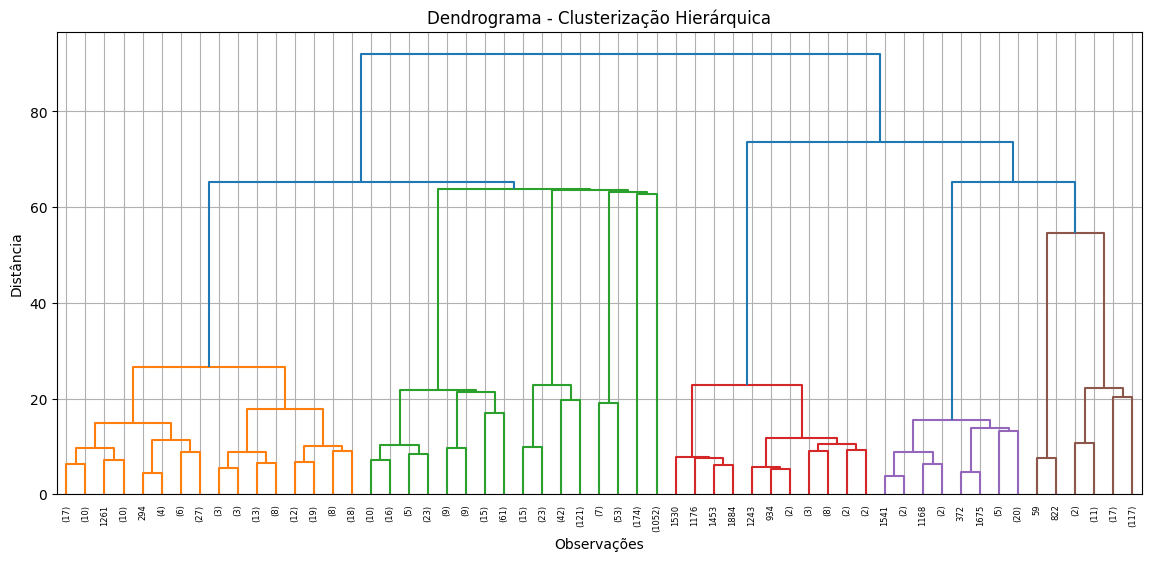

In [21]:
# ============================================================
# EXECUÇÃO DO DENDROGRAMA
# ============================================================

plotar_dendrograma(
    X=df_prep_norm,
    metodo="ward",
    amostra=2000
)

In [32]:
# ============================================================
# ESCOLHA DO NÚMERO DE CLUSTERS
# ============================================================

n_clusters_escolhido = 9

# ============================================================
# EXECUÇÃO DO MODELO
# ============================================================

def executar_hierarquico(
    X,
    n_clusters,
    linkage_method="ward"
):
    """
    Executa Clusterização Hierárquica Aglomerativa.
    """

    modelo = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage_method
    )

    labels = modelo.fit_predict(X)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    silhouette = silhouette_score(X, labels)

    davies = davies_bouldin_score(X, labels)

    calinski = calinski_harabasz_score(X, labels)

    resultados = {
        "modelo": modelo,
        "labels": labels,
        "n_clusters": n_clusters,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies,
        "calinski_harabasz_score": calinski
    }

    return resultados


# ============================================================
# EXECUÇÃO FINAL
# ============================================================

df_sample = df_prep_norm.sample(
    n=2000,
    random_state=42
)

resultados_hierarquico = executar_hierarquico(
    X=df_sample,
    n_clusters=n_clusters_escolhido,
    linkage_method="ward"
)


# ============================================================
# RESULTADOS
# ============================================================

print("=" * 50)
print("RESULTADOS - CLUSTERIZAÇÃO HIERÁRQUICA")
print("=" * 50)

print(f"Número de clusters: "
      f"{resultados_hierarquico['n_clusters']}")

print(f"Silhouette Score: "
      f"{resultados_hierarquico['silhouette_score']:.4f}")

print(f"Davies-Bouldin Score: "
      f"{resultados_hierarquico['davies_bouldin_score']:.4f}")

print(f"Calinski-Harabasz Score: "
      f"{resultados_hierarquico['calinski_harabasz_score']:.2f}")

# ============================================================
# ADICIONA CLUSTERS AO DATAFRAME
# ============================================================

df_sample_original = df.loc[df_sample.index].copy()

df_sample_original["cluster_hierarquico"] = (
    resultados_hierarquico["labels"]
)

# ============================================================
# DISTRIBUIÇÃO DOS CLUSTERS
# ============================================================

print("\nDistribuição dos clusters:\n")

print(
    df_sample_original["cluster_hierarquico"]
    .value_counts()
    .sort_index()
)

# ============================================================
# EXEMPLO DE INSPEÇÃO
# ============================================================

cluster_exemplo = 0

print("\nExemplos de músicas do cluster:\n")

print(
    df_sample_original[df_sample_original["cluster_hierarquico"] == cluster_exemplo][
        ["track_name", "artists", "track_genre"]
    ].head(10))

RESULTADOS - CLUSTERIZAÇÃO HIERÁRQUICA
Número de clusters: 9
Silhouette Score: 0.1222
Davies-Bouldin Score: 1.8065
Calinski-Harabasz Score: 117.97

Distribuição dos clusters:

cluster_hierarquico
0    1052
1     149
2     201
3     160
4      33
5     148
6      23
7      60
8     174
Name: count, dtype: int64

Exemplos de músicas do cluster:

                                               track_name  \
113186                                      No Other Name   
42819                                      Failed Organum   
61000                                               月の大きさ   
96815                              Jah Jah Revolta, Pt. 2   
18939                           Please Stop Communicating   
87169                 Proibida Pra Mim (Grazon) - Ao Vivo   
108051                                                Sur   
87994                                     O Sopro do Fole   
49636   Me Gabber - DJ Paul Elstak & The BeatKrusher R...   
66388                                       

## Limitação Visual e Transição para Avaliação Quantitativa

Inadequação de Técnicas de Visualização em Baixa Dimensionalidade: A tentativa de visualizar o agrupamento dos dados por meio da redução de dimensionalidade para duas dimensões mostrou-se inadequada. Inicialmente, foi aplicado PCA (Análise de Componentes Principais), porém a forte redução dimensional não preservou variância suficiente da representação original, resultando em sobreposição significativa entre os pontos e dificultando a interpretação real das distâncias e separações entre os grupos.

Adicionalmente, também foram realizados testes com UMAP (Uniform Manifold Approximation and Projection), motivados inclusive por uma sugestão da Trilha B, que indicou a possibilidade de utilizar métodos de projeção para fins exploratórios de visualização, ressaltando que tais abordagens poderiam não produzir separações visualmente satisfatórias dependendo da estrutura intrínseca dos dados. Na prática, os resultados obtidos com UMAP apresentaram comportamento semelhante ao observado com PCA, mantendo elevada sobreposição entre amostras e ausência de fronteiras visuais claras entre os clusters.

Foco em Métricas Analíticas: Diante dessas limitações, optou-se por não fundamentar a análise em inspeções visuais bidimensionais. Para assegurar a explicabilidade técnica do modelo e preservar eficiência e escalabilidade na validação, a avaliação da qualidade, coesão e separação dos agrupamentos passou a ser baseada exclusivamente em métricas matemáticas objetivas, como Silhouette Score e Índice de Davies-Bouldin. Essa abordagem fornece uma interpretação mais robusta, quantitativa e confiável do comportamento dos clusters no espaço original de alta dimensionalidade.

## Interpretação dos Clusters

In [23]:
# ================================================================
# CARACTERIZAÇÃO DOS CLUSTERS GERADOS PELO CLUSTERING HIERÁRQUICO
# ================================================================

# Médias das features por cluster
perfil_clusters = df_sample_original.groupby("cluster_hierarquico")[
    [
        "danceability",
        "energy",
        "valence",
        "acousticness",
        "speechiness",
        "instrumentalness",
        "tempo"
    ]
].mean()

# ============================================================
# FUNÇÃO DE INTERPRETAÇÃO
# ============================================================

def interpretar_cluster(linha):

    descricao = []

    # --------------------------------------------------------
    # Danceability
    # --------------------------------------------------------

    if linha["danceability"] >= 0.65:
        descricao.append("muito dançante")

    elif linha["danceability"] >= 0.50:
        descricao.append("moderadamente dançante")

    else:
        descricao.append("pouco dançante")

    # --------------------------------------------------------
    # Energy
    # --------------------------------------------------------

    if linha["energy"] >= 0.70:
        descricao.append("alta energia")

    elif linha["energy"] >= 0.50:
        descricao.append("energia moderada")

    else:
        descricao.append("baixa energia")

    # --------------------------------------------------------
    # Valence
    # --------------------------------------------------------

    if linha["valence"] >= 0.60:
        descricao.append("perfil mais positivo/feliz")

    elif linha["valence"] >= 0.40:
        descricao.append("perfil emocional equilibrado")

    else:
        descricao.append("perfil mais melancólico")

    # --------------------------------------------------------
    # Acousticness
    # --------------------------------------------------------

    if linha["acousticness"] >= 0.50:
        descricao.append("forte característica acústica")

    elif linha["acousticness"] >= 0.30:
        descricao.append("mistura acústica/digital")

    else:
        descricao.append("forte produção eletrônica")

    # --------------------------------------------------------
    # Speechiness
    # --------------------------------------------------------

    if linha["speechiness"] >= 0.15:
        descricao.append("maior presença de fala/rap")

    # --------------------------------------------------------
    # Instrumentalness
    # --------------------------------------------------------

    if linha["instrumentalness"] >= 0.50:
        descricao.append("predominantemente instrumental")

    elif linha["instrumentalness"] >= 0.20:
        descricao.append("presença instrumental moderada")

    # --------------------------------------------------------
    # Tempo
    # --------------------------------------------------------

    if linha["tempo"] >= 130:
        descricao.append("tempo acelerado")

    elif linha["tempo"] <= 100:
        descricao.append("tempo mais lento")

    return ", ".join(descricao)


# ============================================================
# GERA DESCRIÇÕES
# ============================================================

print("=" * 70)
print("PERFIL DOS CLUSTERS GERADOS PELO CLUSTERING HIERÁRQUICO")
print("=" * 70)

for cluster, linha in perfil_clusters.iterrows():

    if cluster==-1:
        break
    
    descricao = interpretar_cluster(linha)

    print(f"\nCluster {cluster}")
    print("-" * 50)

    print(descricao)

    print("\nMédias:")
    print(linha.round(3))

PERFIL DOS CLUSTERS GERADOS PELO CLUSTERING HIERÁRQUICO

Cluster 0
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional equilibrado, forte produção eletrônica

Médias:
danceability          0.572
energy                0.665
valence               0.477
acousticness          0.290
speechiness           0.090
instrumentalness      0.147
tempo               122.604
Name: 0, dtype: float64

Cluster 1
--------------------------------------------------
pouco dançante, baixa energia, perfil mais melancólico, forte característica acústica

Médias:
danceability          0.444
energy                0.470
valence               0.384
acousticness          0.546
speechiness           0.064
instrumentalness      0.187
tempo               123.646
Name: 1, dtype: float64

Cluster 2
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional equilibrado, forte produção eletrônica

Médias:
danceabil

In [24]:
# ============================================================
# CARACTERIZAÇÃO DOS CLUSTERS GERADOS PELO K-MEANS
# ============================================================

# Médias das features por cluster
perfil_clusters = df.groupby("cluster_kmeans")[
    [
        "danceability",
        "energy",
        "valence",
        "acousticness",
        "speechiness",
        "instrumentalness",
        "tempo"
    ]
].mean()

# ============================================================
# FUNÇÃO DE INTERPRETAÇÃO
# ============================================================

def interpretar_cluster(linha):

    descricao = []

    # --------------------------------------------------------
    # Danceability
    # --------------------------------------------------------

    if linha["danceability"] >= 0.65:
        descricao.append("muito dançante")

    elif linha["danceability"] >= 0.50:
        descricao.append("moderadamente dançante")

    else:
        descricao.append("pouco dançante")

    # --------------------------------------------------------
    # Energy
    # --------------------------------------------------------

    if linha["energy"] >= 0.70:
        descricao.append("alta energia")

    elif linha["energy"] >= 0.50:
        descricao.append("energia moderada")

    else:
        descricao.append("baixa energia")

    # --------------------------------------------------------
    # Valence
    # --------------------------------------------------------

    if linha["valence"] >= 0.60:
        descricao.append("perfil mais positivo/feliz")

    elif linha["valence"] >= 0.40:
        descricao.append("perfil emocional equilibrado")

    else:
        descricao.append("perfil mais melancólico")

    # --------------------------------------------------------
    # Acousticness
    # --------------------------------------------------------

    if linha["acousticness"] >= 0.50:
        descricao.append("forte característica acústica")

    elif linha["acousticness"] >= 0.30:
        descricao.append("mistura acústica/digital")

    else:
        descricao.append("forte produção eletrônica")

    # --------------------------------------------------------
    # Speechiness
    # --------------------------------------------------------

    if linha["speechiness"] >= 0.15:
        descricao.append("maior presença de fala/rap")

    # --------------------------------------------------------
    # Instrumentalness
    # --------------------------------------------------------

    if linha["instrumentalness"] >= 0.50:
        descricao.append("predominantemente instrumental")

    elif linha["instrumentalness"] >= 0.20:
        descricao.append("presença instrumental moderada")

    # --------------------------------------------------------
    # Tempo
    # --------------------------------------------------------

    if linha["tempo"] >= 130:
        descricao.append("tempo acelerado")

    elif linha["tempo"] <= 100:
        descricao.append("tempo mais lento")

    return ", ".join(descricao)


# ============================================================
# GERA DESCRIÇÕES
# ============================================================

print("=" * 70)
print("PERFIL DOS CLUSTERS GERADOS PELO K-MEANS")
print("=" * 70)

for cluster, linha in perfil_clusters.iterrows():

    descricao = interpretar_cluster(linha)

    print(f"\nCluster {cluster}")
    print("-" * 50)

    print(descricao)

    print("\nMédias:")
    print(linha.round(3))

PERFIL DOS CLUSTERS GERADOS PELO K-MEANS

Cluster 0
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional equilibrado, mistura acústica/digital

Médias:
danceability          0.598
energy                0.666
valence               0.500
acousticness          0.301
speechiness           0.088
instrumentalness      0.170
tempo               121.788
Name: 0, dtype: float64

Cluster 1
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional equilibrado, forte produção eletrônica

Médias:
danceability          0.570
energy                0.657
valence               0.474
acousticness          0.297
speechiness           0.078
instrumentalness      0.133
tempo               122.747
Name: 1, dtype: float64

Cluster 2
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional equilibrado, forte produção eletrônica

Médias:
danceability 

In [25]:
# ============================================================
# CARACTERIZAÇÃO DOS CLUSTERS GERADOS PELO GMM
# ============================================================

# Médias das features por cluster
perfil_clusters = df.groupby("cluster_gmm")[
    [
        "danceability",
        "energy",
        "valence",
        "acousticness",
        "speechiness",
        "instrumentalness",
        "tempo"
    ]
].mean()

# ============================================================
# FUNÇÃO DE INTERPRETAÇÃO
# ============================================================

def interpretar_cluster(linha):

    descricao = []

    # --------------------------------------------------------
    # Danceability
    # --------------------------------------------------------

    if linha["danceability"] >= 0.65:
        descricao.append("muito dançante")

    elif linha["danceability"] >= 0.50:
        descricao.append("moderadamente dançante")

    else:
        descricao.append("pouco dançante")

    # --------------------------------------------------------
    # Energy
    # --------------------------------------------------------

    if linha["energy"] >= 0.70:
        descricao.append("alta energia")

    elif linha["energy"] >= 0.50:
        descricao.append("energia moderada")

    else:
        descricao.append("baixa energia")

    # --------------------------------------------------------
    # Valence
    # --------------------------------------------------------

    if linha["valence"] >= 0.60:
        descricao.append("perfil mais positivo/feliz")

    elif linha["valence"] >= 0.40:
        descricao.append("perfil emocional equilibrado")

    else:
        descricao.append("perfil mais melancólico")

    # --------------------------------------------------------
    # Acousticness
    # --------------------------------------------------------

    if linha["acousticness"] >= 0.50:
        descricao.append("forte característica acústica")

    elif linha["acousticness"] >= 0.30:
        descricao.append("mistura acústica/digital")

    else:
        descricao.append("forte produção eletrônica")

    # --------------------------------------------------------
    # Speechiness
    # --------------------------------------------------------

    if linha["speechiness"] >= 0.15:
        descricao.append("maior presença de fala/rap")

    # --------------------------------------------------------
    # Instrumentalness
    # --------------------------------------------------------

    if linha["instrumentalness"] >= 0.50:
        descricao.append("predominantemente instrumental")

    elif linha["instrumentalness"] >= 0.20:
        descricao.append("presença instrumental moderada")

    # --------------------------------------------------------
    # Tempo
    # --------------------------------------------------------

    if linha["tempo"] >= 130:
        descricao.append("tempo acelerado")

    elif linha["tempo"] <= 100:
        descricao.append("tempo mais lento")

    return ", ".join(descricao)


# ============================================================
# GERA DESCRIÇÕES
# ============================================================

print("=" * 70)
print("PERFIL DOS CLUSTERS GERADOS PELO GMM")
print("=" * 70)

for cluster, linha in perfil_clusters.iterrows():

    descricao = interpretar_cluster(linha)

    print(f"\nCluster {cluster}")
    print("-" * 50)

    print(descricao)

    print("\nMédias:")
    print(linha.round(3))

PERFIL DOS CLUSTERS GERADOS PELO GMM

Cluster 0
--------------------------------------------------
moderadamente dançante, alta energia, perfil emocional equilibrado, forte produção eletrônica

Médias:
danceability          0.595
energy                0.702
valence               0.463
acousticness          0.222
speechiness           0.100
instrumentalness      0.167
tempo               124.050
Name: 0, dtype: float64

Cluster 1
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional equilibrado, mistura acústica/digital

Médias:
danceability          0.559
energy                0.643
valence               0.473
acousticness          0.316
speechiness           0.073
instrumentalness      0.147
tempo               122.046
Name: 1, dtype: float64

Cluster 2
--------------------------------------------------
pouco dançante, baixa energia, perfil mais melancólico, forte característica acústica, presença instrumental moderada

Médias:
d

In [26]:
# ============================================================
# CARACTERIZAÇÃO DOS CLUSTERS GERADOS PELO DBSCAN
# ============================================================

# Médias das features por cluster
perfil_clusters = df.groupby("cluster_dbscan")[
    [
        "danceability",
        "energy",
        "valence",
        "acousticness",
        "speechiness",
        "instrumentalness",
        "tempo"
    ]
].mean()

# ============================================================
# FUNÇÃO DE INTERPRETAÇÃO
# ============================================================

def interpretar_cluster(linha):

    descricao = []

    # --------------------------------------------------------
    # Danceability
    # --------------------------------------------------------

    if linha["danceability"] >= 0.65:
        descricao.append("muito dançante")

    elif linha["danceability"] >= 0.50:
        descricao.append("moderadamente dançante")

    else:
        descricao.append("pouco dançante")

    # --------------------------------------------------------
    # Energy
    # --------------------------------------------------------

    if linha["energy"] >= 0.70:
        descricao.append("alta energia")

    elif linha["energy"] >= 0.50:
        descricao.append("energia moderada")

    else:
        descricao.append("baixa energia")

    # --------------------------------------------------------
    # Valence
    # --------------------------------------------------------

    if linha["valence"] >= 0.60:
        descricao.append("perfil mais positivo/feliz")

    elif linha["valence"] >= 0.40:
        descricao.append("perfil emocional equilibrado")

    else:
        descricao.append("perfil mais melancólico")

    # --------------------------------------------------------
    # Acousticness
    # --------------------------------------------------------

    if linha["acousticness"] >= 0.50:
        descricao.append("forte característica acústica")

    elif linha["acousticness"] >= 0.30:
        descricao.append("mistura acústica/digital")

    else:
        descricao.append("forte produção eletrônica")

    # --------------------------------------------------------
    # Speechiness
    # --------------------------------------------------------

    if linha["speechiness"] >= 0.15:
        descricao.append("maior presença de fala/rap")

    # --------------------------------------------------------
    # Instrumentalness
    # --------------------------------------------------------

    if linha["instrumentalness"] >= 0.50:
        descricao.append("predominantemente instrumental")

    elif linha["instrumentalness"] >= 0.20:
        descricao.append("presença instrumental moderada")

    # --------------------------------------------------------
    # Tempo
    # --------------------------------------------------------

    if linha["tempo"] >= 130:
        descricao.append("tempo acelerado")

    elif linha["tempo"] <= 100:
        descricao.append("tempo mais lento")

    return ", ".join(descricao)


# ============================================================
# GERA DESCRIÇÕES
# ============================================================

print("=" * 70)
print("PERFIL DOS CLUSTERS GERADOS PELO DBSCAN")
print("=" * 70)

for cluster, linha in perfil_clusters.iterrows():

    descricao = interpretar_cluster(linha)

    print(f"\nCluster {cluster}")
    print("-" * 50)

    print(descricao)

    print("\nMédias:")
    print(linha.round(3))

PERFIL DOS CLUSTERS GERADOS PELO DBSCAN

Cluster -1
--------------------------------------------------
pouco dançante, energia moderada, perfil mais melancólico, forte característica acústica, maior presença de fala/rap, presença instrumental moderada, tempo mais lento

Médias:
danceability         0.387
energy               0.564
valence              0.286
acousticness         0.569
speechiness          0.387
instrumentalness     0.325
tempo               96.976
Name: -1, dtype: float64

Cluster 0
--------------------------------------------------
moderadamente dançante, alta energia, perfil emocional equilibrado, forte produção eletrônica

Médias:
danceability          0.595
energy                0.702
valence               0.463
acousticness          0.222
speechiness           0.100
instrumentalness      0.166
tempo               124.045
Name: 0, dtype: float64

Cluster 1
--------------------------------------------------
moderadamente dançante, energia moderada, perfil emocional e

## Auditoria dos clusters

Após a avaliação quantitativa dos algoritmos, será realizada uma auditoria humana dos clusters gerados. Essa etapa consiste na inspeção manual de músicas pertencentes aos agrupamentos escolhidos por cada algoritmo, utilizando informações como nome da faixa, artista e gênero musical. O objetivo foi verificar se os clusters apresentavam coerência semântica e características musicais semelhantes, complementando as métricas matemáticas com uma análise qualitativa dos resultados.

O primeiro cluster a ser avaliado será o cluster 2, obtido pelo algortimo de Clustering Hierárquico, que foi descrito como "moderadamente dançante, energia moderada, perfil emocional equilibrado, forte produção eletrônica". Esse agrupamento fez sentido pois as musicas de fato possuem perfis semelhantes. O algoritmo conseguiu formar um grupo semanticamente coerente para esse perfil musical.

In [27]:
df_sample_original[df_sample_original['cluster_hierarquico']==2][
    ["track_name", "artists", "track_genre"]
].sample(10, random_state=42)


,track_name,artists,track_genre
58041,Cold,Static-X,industrial
82716,Abandoned,The Lemonheads,power-pop
47514,Figure It Out,Royal Blood,hard-rock
55691,Udd Ja Kale Kanwan,Amandeep Singh,indian
57058,505,Arctic Monkeys,indie
112166,22,Gece,turkish
9203,Digimon,Yung Buda,brazil
65654,The Eve,EXO,k-pop
70668,茫茫到深更,音樂磁場,mandopop
103790,Sweets for My Sweet,The Drifters,soul


O cluster 14 obtido pelo algoritmo K-Means foi descrito como “pouco dançante, baixa energia, perfil mais melancólico, forte característica acústica, maior presença de fala/rap e presença instrumental moderada”. Durante a auditoria humana, observou-se que o agrupamento apresentou relativa diversidade de gêneros musicais, incluindo faixas de dancehall, funk, música religiosa, trance e até sons ambientes para relaxamento. Ainda assim, as músicas compartilhavam características acústicas semelhantes, principalmente baixos níveis de energia, presença significativa de elementos vocais/falados e uma atmosfera mais suave ou introspectiva. Isso sugere que o algoritmo conseguiu identificar padrões sonoros comuns mesmo entre gêneros musicalmente distintos.

In [28]:
df[df['cluster_kmeans']==14][
    ["track_name", "artists", "track_genre"]
].sample(10, random_state=42)

,track_name,artists,track_genre
60042,Show Me The Wine,Vybz Kartel,j-dance
94940,SkinTheBone,NothingNothingNothing,sad
18845,Vegas Ladies,Kathleen Madigan,comedy
21785,Neva Figet - 2022 Remastered Version,Quada;Moonskull,dancehall
60728,I'll Take U There,Vybz Kartel,j-dance
37686,Ruas da Sul,Mc Kadu;MC Leozinho ZS;Kotim;Mc Lele JP;Love Funk,funk
21984,Work - Mo Bible,Poplane,dancehall
113221,Hosanna,Hillsong Worship;Brooke Ligertwood,world-music
110534,Giving It Out - Etherwood Remix,Above & Beyond;Zoë Johnston;Etherwood,trance
101961,Pink Noise Waves,Outside Broadcast Recordings,sleep


O cluster 49 obtido pelo algortimo DBSCAN foi descrito como "moderadamente dançante, alta energia, perfil emocional equilibrado, forte característica acústica, maior presença de fala/rap, tempo mais lento". O algoritmo conseguiu formar um grupo semanticamente coerente para esse perfil musical, formado por músicas do gênero de comédia.

In [29]:
df[df['cluster_dbscan']==49][["track_name", "artists", "track_genre"]].sample(10, random_state=42)

,track_name,artists,track_genre
18338,Writing on the Wall,Kyle Kinane,comedy
18028,Salt,Kyle Kinane,comedy
18620,Space,Steve Rannazzisi,comedy
18775,Potheads,Willie Barcena,comedy
18240,Gonna Raise Hell,Kyle Kinane,comedy
18178,Dream Police,Kyle Kinane,comedy
18579,Montana and the Flea Market,Josh Sneed,comedy
18295,Eat Your Carrots,Chad Daniels,comedy
18443,"Rock, Paper, Scissors, Jesus",Chad Daniels,comedy
18283,The Semicolon,Dan Cummins,comedy


O cluster 4 obtido pelo algoritmo GMM foi descrito como “moderadamente dançante, energia moderada, perfil emocional equilibrado e mistura acústica/digital”. Observou-se que esse agrupamento apresentou maior diversidade de estilos e artistas. Ainda assim, o agrupamento fez sentido, pois as músicas compartilhavam características acústicas semelhantes, especialmente em relação ao equilíbrio entre elementos eletrônicos e acústicos e aos níveis intermediários de energia e danceability.

In [30]:
df[df['cluster_gmm']==4][
    ["track_name", "artists", "track_genre"]
].sample(10, random_state=42)

,track_name,artists,track_genre
100756,Beautiful,Me First and the Gimme Gimmes,ska
27794,Remind Me - S.P.Y Remix,BCee;Charlotte Haining;S.P.Y,drum-and-bass
78468,Von vorne nach hinten...von links nach rechts ...,Mickie Krause,party
23477,Strangers (TWOPILOTS Remix),FDVM;TWOPILOTS,deep-house
50659,1000 Sanatas,Asspera,heavy-metal
100884,Cambia todo cambia,Los Miserables,ska
92010,Run Rudolph Run,Chuck Berry,rockabilly
105735,Kankickz,Type.Raw,study
90499,Tiempo (with José José),Marco Antonio Muñiz;José José,rock-n-roll
21466,Protocol,Skeng;Tommy Lee Sparta,dancehall


## 3.6 Resultados preliminares da modelagem

| Algoritmo   | Nº Clusters Escolhido | Silhouette | Davies-Bouldin | Calinski-Harabasz | Observações                                             |
|-------------|----------------------|-------------|------------------|-------------------|----------------------------------------------------------|
| K-Means     | 16                   | 0.2917      | 1.2462           | 9039.91           | Melhor separação geral entre os métodos testados         |
| DBSCAN      | 66                   | 0.3028      | 1.7986           | 2280.77           | Detectou muitos grupos e ruídos                          |
| GMM         | 9                    | 0.1720      | 2.1288           | 6325.72           | Separação moderada, maior flexibilidade probabilística   |
| Hierárquico | 9                    | 0.1222      | 1.8065           | 117.97            | Baixa separação e alto custo computacional               |

### Análise Comparativa dos Algoritmos de Agrupamento:

Os algoritmos avaliados apresentaram comportamentos bastante distintos em relação à qualidade dos agrupamentos, interpretabilidade, estabilidade e custo computacional. Por esse motivo, a comparação não deve ser realizada apenas com base em uma métrica isolada, mas considerando o conjunto de características de cada abordagem.

O K-Means apresentou o melhor equilíbrio geral entre qualidade da solução e viabilidade prática. O modelo produziu 16 clusters, obtendo Silhouette Score de 0,2917 e o menor Davies-Bouldin Score entre os algoritmos testados (1,2462), indicando grupos relativamente compactos e bem separados. O elevado valor de Calinski-Harabasz também sugere boa estruturação dos clusters. Além disso, o algoritmo apresentou execução rápida, baixo custo computacional e boa estabilidade, mantendo resultados semelhantes mesmo com pequenas variações de inicialização e parâmetros. Apesar da quantidade relativamente alta de clusters, os grupos obtidos permaneceram interpretáveis no contexto musical, permitindo identificar padrões relacionados a energia, dançabilidade, instrumentalidade e acústica das músicas.

O DBSCAN apresentou o maior Silhouette Score (0,3028), o que inicialmente sugere uma boa separação entre os grupos. Entretanto, a análise qualitativa mostrou limitações importantes. O algoritmo gerou 66 clusters diferentes e classificou 672 observações como ruído, produzindo uma solução excessivamente fragmentada. Além disso, o método demonstrou alta sensibilidade aos parâmetros, especialmente ao valor de eps. Pequenas alterações nesse parâmetro modificavam drasticamente o número de clusters e a quantidade de pontos classificados como ruído, evidenciando baixa estabilidade da solução. Embora o DBSCAN seja eficiente para detectar outliers e estruturas de formato arbitrário, sua interpretação se tornou mais difícil neste problema, já que muitos grupos continham pouquíssimas observações e pouca coerência semântica entre músicas.

O Gaussian Mixture Model (GMM) apresentou resultados intermediários. O modelo gerou 9 componentes, porém com Silhouette Score relativamente baixo (0,1720) e Davies-Bouldin Score mais elevado (2,1288), indicando menor separação entre os grupos. Ainda assim, o GMM possui uma característica relevante: a abordagem probabilística. Diferentemente do K-Means, o algoritmo permite representar sobreposição entre clusters, algo plausível em dados musicais, onde uma música pode compartilhar características de diferentes estilos. Dessa forma, embora as métricas quantitativas tenham sido inferiores, o modelo apresentou boa adequação conceitual ao problema. Os critérios AIC e BIC também auxiliaram na escolha do número de componentes mais apropriado.

A clusterização hierárquica apresentou as métricas menos favoráveis entre os métodos avaliados. O modelo obteve Silhouette Score de 0,1222 e Calinski-Harabasz Score significativamente inferior aos demais algoritmos, sugerindo baixa separação e menor coesão entre os grupos. Além disso, o método apresentou elevado custo computacional. A execução com o dataset completo não foi viável devido ao consumo excessivo de memória e processamento, sendo necessário utilizar uma amostra reduzida dos dados para permitir a execução do algoritmo. Isso evidencia uma limitação importante de escalabilidade da abordagem hierárquica em bases grandes.

Apesar das métricas inferiores, a clusterização hierárquica revelou um aspecto interessante na análise qualitativa: os clusters formados apresentaram maior diversidade interna. Isso pode ser observado no dendrograma e nas médias das features por grupo, indicando que o método foi menos rígido na separação das músicas. Em alguns casos, essa característica pode ser útil para exploração de dados, pois permite visualizar relações graduais entre diferentes perfis musicais. No entanto, para fins de segmentação mais objetiva e bem definida, essa diversidade interna reduziu a qualidade dos agrupamentos.

De maneira geral, os resultados mostram que cada algoritmo possui vantagens e limitações específicas. O K-Means apresentou o melhor equilíbrio entre desempenho quantitativo, interpretabilidade, estabilidade e custo computacional, tornando-se a solução mais adequada para o problema proposto. O DBSCAN destacou-se pela capacidade de detectar ruídos e estruturas locais, mas apresentou forte instabilidade paramétrica e excesso de fragmentação. O GMM ofereceu uma modelagem probabilística mais flexível e conceitualmente interessante para dados musicais, embora com menor separação entre clusters. Já a clusterização hierárquica foi mais útil como ferramenta exploratória e visual, mas apresentou limitações práticas importantes relacionadas à escalabilidade e à definição dos grupos.

### Interpretabilidade dos Clusters Gerados em Cada Algoritmo:

A interpretabilidade dos clusters foi um aspecto importante na avaliação dos modelos, especialmente considerando o contexto musical do dataset. Mais do que apenas obter bons valores de métricas internas, buscou-se identificar agrupamentos que pudessem ser compreendidos semanticamente a partir das características acústicas das músicas. Nesse sentido, o K-Means apresentou maior facilidade de interpretação, pois os clusters formados mostraram padrões relativamente consistentes em atributos como energy, danceability, acousticness e instrumentalness. Isso permitiu associar determinados grupos a perfis musicais mais dançantes, acústicos, instrumentais ou energéticos, tornando os resultados mais úteis para análise exploratória e possíveis aplicações em recomendação musical.

Observou-se a formação de alguns macroperfis musicais principais. Parte dos clusters concentrou músicas mais energéticas e dançantes, com baixa acousticness, representando faixas mais próximas de estilos pop, eletrônicos e dance. Outros grupos apresentaram menor energia e maior acousticness, indicando músicas mais suaves, acústicas e introspectivas. Também foi identificado um cluster bastante distinto, caracterizado por elevada instrumentalness e baixíssimos níveis de energy e valence, sugerindo músicas instrumentais, ambientes sonoros ou faixas experimentais. Além disso, diversos clusters apresentaram médias muito semelhantes entre si, especialmente os grupos centrais do modelo. Isso sugere que o número de clusters escolhido pode ter sido relativamente alto, levando o algoritmo a subdividir regiões muito próximas do espaço de atributos. Ainda assim, os agrupamentos encontrados permitiram identificar padrões musicais relevantes e coerentes com as características acústicas presentes no dataset.

Também foi realizada uma auditoria humana dos clusters por meio da inspeção manual de músicas pertencentes a diferentes agrupamentos, utilizando informações como nome da faixa, artista e gênero musical. De maneira geral, observou-se que os clusters do K-Means apresentaram boa coerência semântica, agrupando músicas com características sonoras semelhantes de forma consistente. Essa validação qualitativa reforçou os resultados obtidos pelas métricas quantitativas e contribuiu para aumentar a confiabilidade da segmentação produzida pelo modelo.

O DBSCAN, apesar de apresentar forte fragmentação e gerar uma quantidade elevada de clusters, mostrou resultados interessantes durante a auditoria humana. Em especial, observou-se que o algoritmo conseguiu agrupar de forma bastante consistente músicas do gênero comédia e conteúdos com forte presença de fala, identificando corretamente padrões associados a altos valores de speechiness. Isso demonstra a capacidade do DBSCAN de detectar estruturas locais específicas e grupos muito particulares dentro do espaço acústico. Entretanto, muitos outros clusters apresentaram poucas observações ou diferenças pouco significativas entre si, reduzindo a clareza global da segmentação.

Já o GMM apresentou uma interpretação intermediária, pois sua abordagem probabilística permite representar sobreposição entre perfis musicais, algo coerente com o problema analisado. No entanto, durante a auditoria qualitativa, os agrupamentos mostraram menor separação semântica e maior mistura entre perfis musicais distintos, dificultando interpretações mais objetivas dos clusters encontrados. A clusterização hierárquica, por sua vez, produziu clusters mais heterogêneos e diversos internamente, o que dificultou a segmentação objetiva e gerou agrupamentos menos consistentes durante a inspeção manual das músicas.

Em relação à adequação ao problema, observou-se que diferentes algoritmos atendem objetivos distintos dentro da análise musical. O K-Means mostrou-se mais adequado para segmentação clara e operacional dos dados, especialmente em cenários que exigem agrupamentos relativamente estáveis, interpretáveis e computacionalmente eficientes. O GMM apresentou boa adequação conceitual ao domínio musical devido à possibilidade de modelar incerteza e sobreposição entre clusters, refletindo melhor a natureza subjetiva e híbrida dos gêneros musicais. O DBSCAN demonstrou utilidade na identificação de outliers e estruturas locais específicas, enquanto a clusterização hierárquica se mostrou mais apropriada para exploração visual e compreensão das relações graduais entre grupos.

As diretrizes de monitoramento e avaliação também foram consideradas durante a modelagem. A análise não se limitou a uma única métrica, utilizando simultaneamente Silhouette Score, Davies-Bouldin e Calinski-Harabasz para avaliar separação, coesão e qualidade estrutural dos clusters. Além disso, foi realizado acompanhamento da estabilidade dos algoritmos diante da alteração de parâmetros, especialmente no DBSCAN, que apresentou forte sensibilidade ao parâmetro eps. O custo computacional e a escalabilidade também foram monitorados, evidenciados pela necessidade de amostragem na clusterização hierárquica devido às limitações de memória e processamento.

Por fim, a explicabilidade dos resultados foi tratada como um critério relevante na escolha do modelo mais adequado. Em aplicações reais, especialmente em sistemas de recomendação e análise musical, é importante que os agrupamentos possam ser compreendidos e justificados. Nesse aspecto, o K-Means apresentou vantagem por gerar clusters relativamente claros e apresentar ótimas medidas de desempenho.

A possibilidade de interpretar os grupos em termos musicais concretos contribui para maior transparência do processo analítico e facilita a validação qualitativa dos resultados obtidos.

## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| Monitoramento e Avaliação | Uso de métricas quantitativas como Silhouette Score, Davies-Bouldin e Calinski-Harabasz; comparação entre K-Means, DBSCAN e GMM | Uso das mesmas métricas, comparação entre algoritmos e análise adicional de riscos metodológicos, custo computacional e comportamento geométrico dos clusters | SIM | As duas trilhas aplicaram corretamente métricas de avaliação e comparação entre algoritmos. A Trilha B avançou ao discutir mais as limitações estatísticas e computacionais, impacto da dimensionalidade e necessidade de análise dos clusters além do score médio. |
| Explicabilidade | Sugestão de descrição semântica dos clusters e validação usando track_genre | Descrição semântica detalhada dos clusters, auditoria manual de músicas, interpretação dos centroides em escala original e justificativa explícita dos parâmetros escolhidos | SIM | A Trilha B tornou a explicabilidade parte central do pipeline analítico. Além de sugerir nomes semânticos para os clusters, propôs validação humana das músicas agrupadas e recuperação dos centroides na escala original para interpretação direta das características acústicas. Isso aumenta significativamente a transparência e a capacidade de justificar os resultados do modelo. |

### Discussão

As duas trilhas demonstraram aderência às diretrizes propostas para IA responsável em tarefas de clusterização, principalmente ao reconhecer que problemas não supervisionados exigem validação baseada em métricas internas e interpretação humana dos resultados.

Na Diretriz 1, ambas utilizaram métricas quantitativas adequadas para avaliar coesão e separação dos clusters, além de recomendar comparação entre diferentes algoritmos. Contudo, a Trilha B apresentou melhorias ao discutir explicitamente limitações metodológicas dos algoritmos, como sensibilidade do DBSCAN à densidade, viés geométrico do K-Means e problemas relacionados à alta dimensionalidade. Essa ampliação fortalece a análise crítica da qualidade dos agrupamentos. 

Na Diretriz 2, a diferença entre as abordagens foi mais significativa. A Trilha A já propunha interpretação semântica dos clusters e comparação com gêneros musicais conhecidos. Porém, a Trilha B aprofundou essa preocupação ao exigir auditoria manual das músicas agrupadas e recuperação dos centroides na escala original após a normalização. Isso permite interpretar diretamente características como energia, valência e acusticidade dos grupos formados, tornando o modelo mais transparente e justificável.

Além disso, a Trilha B também relacionou explicitamente escolhas metodológicas à explicabilidade. Um exemplo foi a discussão sobre PCA e UMAP: embora essas técnicas possam melhorar separação geométrica, a resposta destacou que elas reduzem a capacidade de interpretar semanticamente os clusters, o que representa um trade-off importante entre desempenho e transparência.

# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

Os quatro algoritmos testados produziram agrupamentos com qualidade variada, mas todos com sentido técnico e interpretável dentro do contexto musical do Spotify Tracks Dataset.

Os padrões encontrados fazem sentido?
Sim. O K-Means (k=16) gerou grupos distinguíveis por perfis acústicos: músicas energéticas e dançantes com baixa acousticness, músicas suaves e acústicas com baixa energia, e um cluster distinto de faixas predominantemente instrumentais com valência baixa. 

O DBSCAN identificou corretamente músicas de comédia e conteúdos com alto speechiness num único grupo (cluster 49), o que demonstra que o algoritmo capturou estruturas locais específicas com precisão. O GMM e o Hierárquico, embora com métricas inferiores, também geraram grupos com alguma coerência sonora.

Eles são relevantes para o problema de negócio?
Sim. O objetivo era identificar perfis musicais baseados em características acústicas para apoiar sistemas de recomendação e curadoria de playlists. Os macroperfis encontrados pelo K-Means, músicas festivas/eletrônicas, faixas acústicas/introspectivas e conteúdos instrumentais/ambientes, são diretamente aplicáveis a esse caso de uso. A segmentação obtida poderia, por exemplo, fundamentar playlists automáticas para treino, relaxamento ou festa, independentemente do gênero declarado da faixa.

Há resultados triviais, redundantes ou pouco úteis?
Parcialmente. O K-Means com k=16 produziu vários clusters com médias de features muito semelhantes entre si, especialmente nos grupos centrais do espaço de atributos. Isso sugere que o número de clusters pode ter sido ligeiramente alto, levando a uma subdivisão desnecessária de regiões próximas. O DBSCAN gerou 66 clusters, muitos com poucas observações, o que dilui a utilidade prática da segmentação. Esses clusters minoritários do DBSCAN são pouco úteis para recomendação em larga escala.

O desempenho obtido é adequado?
Os Silhouette Scores obtidos, 0,2917 (K-Means), 0,3028 (DBSCAN), 0,1720 (GMM) e 0,1222 (Hierárquico), são modestos. Em dados musicais multidimensionais com grande sobreposição natural entre gêneros e estilos, esses valores são esperados e aceitáveis. O K-Means apresentou o melhor equilíbrio geral: menor Davies-Bouldin (1,2462) e maior Calinski-Harabasz (9039,91), confirmando a melhor separação relativa entre os métodos.

As métricas usadas são compatíveis com a tarefa?
Sim. Silhouette Score, Davies-Bouldin Index e Calinski-Harabasz Index são métricas internas adequadas para clusterização não supervisionada, onde não há rótulos verdadeiros disponíveis. A combinação dos três indicadores permite avaliar simultaneamente coesão interna, separação entre grupos e compacidade relativa. O uso de AIC e BIC para o GMM também foram importantes. A auditoria qualitativa complementou as métricas quantitativas com validação semântica, o que é especialmente relevante dada a natureza subjetiva dos perfis musicais.

Há limitações nos dados ou na modelagem que afetam a conclusão?
Sim, há limitações relevantes. A alta dimensionalidade do dataset após o One-Hot Encoding reduz a eficácia das métricas de distância euclidiana, afetando especialmente o K-Means e o DBSCAN. A remoção de track_genre e popularity antes da modelagem foi necessária para evitar viés. O Clustering Hierárquico precisou ser executado sobre uma amostra de 2.000 registros (de ~114.000), tornando seus resultados menos representativos. 

O DBSCAN mostrou alta sensibilidade ao parâmetro eps, o que compromete a estabilidade e reprodutibilidade da solução. Por fim, a sobreposição natural de características acústicas entre gêneros distintos é uma limitação inerente ao problema, músicas de Forró e Synth-pop podem compartilhar padrões acústicos semelhantes, o que o modelo trata como pertencimento ao mesmo cluster.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
|Usar K-Means como baseline com Método do Cotovelo para definir k | Baseline (A) | ACEITA | O método do cotovelo foi aplicado e orientou a escolha de k=16. A sugestão foi tecnicamente correta e viável computacionalmente para o volume de dados. |
| Comparar K-Means, DBSCAN e GMM | Baseline (A) | ACEITA (com adição) | A comparação foi realizada. O grupo adicionou Clustering Hierárquico por influência da Trilha B, ampliando a análise comparativa. |
| Usar Silhouette Score, Davies-Bouldin e Calinski-Harabasz | Baseline (A) | ACEITA | As três métricas foram implementadas para todos os algoritmos. São métricas internas clássicas e adequadas para clusterização sem rótulo verdadeiro. |
| Rejeitar redução de dimensionalidade (PCA) para preservar explicabilidade | Guiada (B) | ACEITA | A tentativa de visualização via PCA 2D demonstrou inadequação: sobreposição severa dos pontos e baixa variância capturada. O grupo optou por focar em métricas analíticas, alinhado à diretriz de Explicabilidade. |
| Tratar track_genre e popularity como atributos sensíveis e removê-los antes da modelagem | Guiada (B) | ACEITA | A popularidade poderia agrupar músicas por sucesso comercial ao invés de perfil sonoro. O track_genre introduziria viés supervisionado num modelo não supervisionado. Ambas as remoções foram justificadas. |
| Realizar auditoria humana dos clusters com inspeção de músicas reais | Guiada (B) | ACEITA | A auditoria foi realizada para clusters selecionados de cada algoritmo. Confirmou coerência semântica do K-Means e do DBSCAN em contextos específicos, complementando as métricas quantitativas. |
| Converter duration_ms para minutos para melhorar interpretabilidade | Baseline (A) | REJEITADA | Após normalização Z-score, a unidade de medida original não impacta o resultado matemático da clusterização. A conversão seria apenas cosmética e não justifica a modificação do pipeline. |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| Sugestão de comparar múltiplos algoritmos sem alertar sobre custo computacional do Hierárquico em ~114k registros | B | A clusterização hierárquica possui complexidade O(n³). Executar sobre o dataset completo é inviável em hardware convencional. A LLM mencionou o custo em termos gerais, mas não alertou explicitamente que seria necessário amostrar os dados. | O grupo limitou a execução hierárquica a uma amostra de 2.000 observações, tornando os resultados menos representativos e comparáveis aos demais algoritmos. |
| A Trilha B sugeriu One-Hot Encoding para track_genre e explicit, mas depois recomendou remover track_genre | B | A LLM foi internamente contraditória: primeiro indicou codificar track_genre e depois orientou sua remoção para evitar viés. Isso gerou ambiguidade sobre o tratamento correto da coluna. | O grupo adotou a segunda orientação (remoção) como mais adequada ao contexto não supervisionado, documentando a justificativa. |
| Ambas as trilhas omitiram que o DBSCAN com eps muito permissivo pode colapsar em um único cluster gigante | A e B | Em datasets densos como o Spotify (114k registros normalizados), eps alto faz o DBSCAN agrupar quase tudo num único cluster. Essa limitação prática não foi alertada. | O grupo testou diferentes valores de eps guiado pelo gráfico K-Distance, encontrando eps=4 como ponto de inflexão razoável. |
| Nenhuma trilha sugeriu validação cruzada ou análise de estabilidade dos clusters com diferentes sementes aleatórias | A e B | A estabilidade da solução não foi avaliada formalmente. Resultados do K-Means podem variar com diferentes valores de RANDOM_STATE. | O grupo fixou RANDOM_STATE=42 em todos os modelos para garantir reprodutibilidade, mas não realizou análise de estabilidade entre sementes. Isso é uma limitação a corrigir na Fase 3. |

### Comentário crítico

As respostas do Gemini Pro foram, em geral, tecnicamente corretas e úteis em ambas as trilhas. O modelo demonstrou bom domínio das técnicas de clusterização e das métricas de avaliação, raramente cometendo erros graves. 

O maior problema identificado não foi alucinação, mas superficialidade seletiva: a LLM tendia a listar algoritmos e métricas de forma correta, mas sem aprofundar restrições práticas de implementação (como o custo computacional real do Clustering Hierárquico em 114k pontos ou a sensibilidade paramétrica extrema do DBSCAN). 

A Trilha B foi notavelmente mais útil por forçar o modelo a raciocinar sobre trade-offs, riscos e limitações, aspectos que a Trilha A simplesmente omitiu. Ainda assim, é importante notar que o modelo da Trilha B pode ter sido influenciado por interações anteriores do mesmo usuário (conta pessoal do Gemini), o que pode ter inflado a qualidade percebida da resposta guiada.


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | Alta: sugeriu algoritmos aplicáveis, métricas corretas e pipeline funcional para o problema. | Alta: mesmas sugestões com detalhamento adicional de riscos e orientações sobre atributos sensíveis. | Ambas foram úteis. A Trilha B agregou valor especialmente na identificação de problemas que a Trilha A ignorou (viés de popularidade, contradição no tratamento do track_genre). |
| Correção técnica | Boa. Poucas inconsistências; os algoritmos e métricas sugeridos eram adequados ao problema. | Boa a muito boa. Mais rigorosa na justificativa das escolhas, porém com inconsistência interna no tratamento do track_genre. | A Trilha B foi ligeiramente mais precisa, mas ambas cometeram a omissão sobre o custo computacional do Hierárquico. |
| Clareza das justificativas | Moderada. Decisões técnicas foram apresentadas sem grande aprofundamento dos motivos. | Alta. Cada sugestão foi acompanhada de raciocínio explícito sobre por quê aquela escolha é mais adequada ao contexto. | A diretriz de Explicabilidade teve efeito direto na qualidade das justificativas da Trilha B. |
| Aderência às diretrizes | Ausente formalmente. A Trilha A não mencionou Monitoramento/Avaliação nem Explicabilidade de forma estruturada. | Presente e explícita. As diretrizes moldaram o raciocínio da LLM e apareceram integradas às recomendações. | Diferença marcante e esperada. A Trilha B demonstrou que a instrução explícita de diretrizes produz respostas mais estruturadas e orientadas a riscos. |
| Qualidade da modelagem | Boa. Propôs K-Means, DBSCAN e GMM com parâmetros razoáveis. | Muito boa. Substituiu GMM por Hierárquico com foco em interpretabilidade visual; propôs parâmetros mais operacionais e discutiu limitações geométricas. | A Trilha B apresentou modelagem conceitualmente mais sofisticada; a Trilha A foi mais pragmática com GMM (adequado ao problema musical). O grupo incorporou ambas, testando os quatro algoritmos. |
| Qualidade da avaliação | Adequada. Sugeriu as três métricas internas padrão e comparação com track_genre. | Superior. Adicionou auditoria humana, recuperação de centroides na escala original e discussão explícita de estabilidade paramétrica. | A Trilha B elevou o padrão de avaliação ao exigir validação qualitativa, não apenas quantitativa. |
| Riscos não tratados | Vários. Omitiu custo computacional do Hierárquico, sensibilidade do DBSCAN e estabilidade do K-Means entre sementes. | Parcialmente tratados. Mencionou viés de popularidade, custo computacional do algoritmo Hierárquico e maldição da dimensionalidade, mas também omitiu análise formal de estabilidade. | Nenhuma das trilhas cobriu completamente os riscos metodológicos. A Trilha B foi mais abrangente, mas ainda deixou lacunas relevantes. |

### Conclusão comparativa

A explicitação das diretrizes de IA responsável na Trilha B produziu mudanças mensuráveis na qualidade das respostas do Gemini Pro, confirmando em grande parte a hipótese experimental do grupo. 

A Trilha B produziu justificativas mais detalhadas e racionalmente fundamentadas para cada escolha metodológica, enquanto a Trilha A apresentou sugestões corretas, porém com menos embasamento crítico. A diretriz de Explicabilidade induziu a LLM a propor auditoria humana dos clusters e recuperação dos centroides em escala original, uma adição que enriqueceu genuinamente o pipeline de avaliação. A diretriz de Monitoramento e Avaliação levou a discussões mais elaboradas sobre trade-offs computacionais e limitações geométricas dos algoritmos.

Por outro lado, a Trilha B introduziu pelo menos um novo trade-off relevante: ao rejeitar PCA e UMAP para além da visualização e enfatizar explicabilidade, a solução perdeu a possibilidade de melhorar a separação geométrica dos clusters em espaços de menor dimensão. A inconsistência interna da LLM sobre o tratamento do track_genre também foi um problema gerado pela tentativa de atender simultaneamente múltiplas diretrizes.

Em síntese, a Trilha B foi superior à Trilha A, ambas produziram soluções válidas e tecnicamente corretas. O valor real da Trilha B foi antecipar riscos e exigir maior rigor metodológico, levando o grupo a tomar decisões mais conscientes sobre atributos sensíveis, métricas de avaliação e validação qualitativa.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | A rejeição do PCA/UMAP como input preservou a capacidade de interpretar os clusters em termos das features originais (energy, danceability, etc.), mas inviabilizou a visualização 2D dos agrupamentos. A tentativa de redução para 2 componentes resultou em sobreposição severa dos pontos, confirmando que a variância das features não se concentra em poucos componentes. | O grupo optou por manter a interpretabilidade, descartando o PCA/UMAP. A avaliação passou a ser fundamentada exclusivamente em métricas analíticas e auditoria humana. |
| Privacidade × utilidade dos dados | A remoção de artistas, nomes de faixas e track_genre eliminou informações potencialmente identificadoras e sensíveis, evitando que o modelo agrupasse músicas por artista ou gênero declarado. Contudo, essas informações foram mantidas em tabela separada para validação qualitativa posterior. | Atributos sensíveis foram removidos do espaço de modelagem, mas retidos como metadados auxiliares para auditoria. Isso equilibrou proteção contra viés e preservação da capacidade de interpretação. |
| Custo computacional × qualidade da solução | O Clustering Hierárquico, algoritmo com maior potencial de interpretação visual via dendrograma, precisou ser executado sobre uma amostra de apenas 2.000 registros (≈1,75% do dataset) devido à sua complexidade O(n³). Isso comprometeu a representatividade dos resultados e gerou o menor Calinski-Harabasz Score (117,97) dentre os algoritmos. | O grupo manteve o algoritmo hierárquico na comparação, mas reconheceu explicitamente que seus resultados têm validade limitada. Para a Fase 3, a abordagem hierárquica pode ser substituída, aplicada com outra estratégia ou apenas como ferramenta exploratória. |
| Simplicidade × completude da análise | O K-Means com k=16 é simples e computacionalmente eficiente, mas o número elevado de clusters dificulta a síntese de perfis musicais claros para o usuário final. Reduzir k melhora a legibilidade dos perfis, mas piora as métricas de separação. | O grupo manteve k=16 com base na análise do cotovelo, priorizando qualidade matemática sobre simplicidade de apresentação. Para a Fase 3, recomenda-se testar k entre 8 e 12 para avaliar o impacto na interpretabilidade prática. |
| Justiça/viés × disponibilidade de atributos | A remoção de popularity evitou que o modelo agrupasse músicas por sucesso comercial, mas também eliminou uma variável com potencial explicativo sobre o comportamento do usuário. Manter popularity poderia gerar clusters fortemente enviesados por visibilidade de mercado, não por similaridade acústica real. | Popularity foi removida da modelagem. A diretriz de Explicabilidade da Trilha B reforçou essa decisão ao alertar que a variável "ofusca a similaridade sonora". |

### Discussão

Os trade-offs identificados foram pertinentes e relevantes ao problema. O mais impactante foi a tensão entre custo computacional e qualidade da solução, que inviabilizou uma comparação justa entre os algoritmos ao forçar a execução hierárquica sobre amostra reduzida. Esse é um problema estrutural para datasets da escala do Spotify Tracks e deve ser endereçado na Fase 3, possivelmente com uso de BIRCH ou mini-batch clustering como alternativas escaláveis.

O trade-off de interpretabilidade versus desempenho, embora clássico, foi relevante aqui porque o problema de negócio exige que os clusters façam sentido para humanos, não apenas para métricas matemáticas. Essa é a razão pela qual a auditoria humana foi incorporada ao pipeline de avaliação e por que o K-Means, mesmo com Silhouette Score marginalmente inferior ao DBSCAN, foi escolhido como a solução mais equilibrada. O trade-off de viés versus utilidade dos dados reforça a importância das diretrizes de IA responsável adotadas, pois sem a reflexão induzida pela Trilha B, a variável popularity poderia ter permanecido no dataset, distorcendo silenciosamente os agrupamentos.


## 4.5 Considerações finais da Fase 2

1. A LLM ajudou em quais partes do trabalho?

A LLM foi especialmente útil nas fases de planejamento e estruturação do trabalho. No Business Understanding, auxiliou na formulação clara do problema de negócio, conectando características acústicas do dataset a aplicações reais em plataformas de streaming musical. No Data Preparation, contribuiu na definição do pipeline de normalização, tratamento de duplicatas e remoção de outliers na variável duration_ms. Na etapa de modelagem, sugeriu algoritmos apropriados, parâmetros iniciais coerentes e métricas de avaliação compatíveis com tarefas de clusterização. A Trilha B também teve papel importante ao recomendar a incorporação de auditoria humana dos clusters como etapa complementar de validação qualitativa. Além disso, a LLM auxiliou na reflexão metodológica sobre limitações do projeto, especialmente ao discutir os riscos de interpretações enviesadas ao relacionar diretamente popularidade musical e atributos sonoros específicos. O objetivo passou a concentrar-se na identificação de perfis sonoros intrínsecos aos dados, buscando verificar se músicas poderiam ser agrupadas por similaridade acústica independentemente do gênero informado, além de identificar grupos associados a características como músicas dançantes, acústicas, energéticas ou calmas. Esse direcionamento contribuiu para uma abordagem mais cautelosa e tecnicamente fundamentada na análise dos agrupamentos.

2. Em quais partes a LLM errou ou foi superficial?

A LLM foi superficial no tratamento de restrições práticas de implementação. A trilha A não alertou adequadamente sobre o custo computacional proibitivo do Clustering Hierárquico em ~114k registros nem sobre a sensibilidade extrema do DBSCAN ao parâmetro eps. Também omitiu a necessidade de análise formal de estabilidade do K-Means entre diferentes sementes aleatórias. A inconsistência interna da Trilha B sobre o tratamento do track_genre (codificar vs. remover) exigiu julgamento para ser resolvida.

3. A Trilha B foi de fato diferente da Trilha A?

Sim, a Trilha B produziu justificativas mais ricas, identificou riscos adicionais (viés de popularidade, contradição no track_genre, maldição da dimensionalidade) e propôs validações qualitativas que a Trilha A não incluiu. Porém, a diferença foi de profundidade e rigor, não de direção técnica. Ambas as trilhas convergiram nos mesmos algoritmos principais e nas mesmas métricas de avaliação.

4. As diretrizes escolhidas tiveram efeito concreto?

Sim. A diretriz de Explicabilidade levou diretamente à rejeição do PCA e do UMAP, à realização da auditoria humana e à remoção de popularity do espaço de modelagem. A diretriz de Monitoramento e Avaliação induziu a análise comparativa com três métricas simultâneas e a discussão explícita sobre estabilidade paramétrica e custo computacional. Esses não foram efeitos superficiais, já que moldaram decisões de pipeline que afetaram os resultados obtidos.

5. Quais sugestões serão levadas para a Fase 3?

Serão mantidos: o pipeline de normalização Z-score; a remoção de atributos sensíveis (popularity, track_genre) da modelagem; o uso de K-Means como algoritmo principal; as três métricas internas (Silhouette, Davies-Bouldin, Calinski-Harabasz) como critério de avaliação quantitativa; e a auditoria humana como validação qualitativa dos clusters. Também será mantida a comparação com GMM, dado seu valor conceitual para o domínio musical.

6. Quais sugestões serão descartadas?

O Clustering Hierárquico sobre o dataset completo será descartado por inviabilidade computacional, podendo ser substituído por BIRCH ou mini-batch clustering em versão exploratória. A visualização 2D via PCA também será descartada como ferramenta de avaliação principal. A sugestão de converter duration_ms para minutos já foi rejeitada.

7. O que ainda precisa ser implementado ou corrigido na versão final?

Para a Fase 3, é necessário realizar análise formal de estabilidade do K-Means com múltiplas sementes aleatórias, testar variações de k (menores do que 16) para avaliar impacto na interpretabilidade, considerar alternativas escaláveis ao Clustering Hierárquico, aprofundar a auditoria humana com mais amostras por cluster e produzir descrições semânticas completas para todos os clusters do modelo escolhido, conectando os perfis acústicos a casos de uso de recomendação musical.

### Próximos passos para a Fase 3

- [X] Corrigir limitações identificadas nas respostas da LLM.
- [X] Consolidar a preparação dos dados.
- [X] Executar modelagem final.
- [X] Avaliar resultados de forma mais completa.
- [X] Integrar análise comparativa baseline × guiada × solução final.
- [X] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [X] identificação do grupo;
- [X] link público do dataset;
- [X] comprovação de que o dataset atende às restrições mínimas;
- [X] descrição do problema de negócio;
- [X] descrição das colunas;
- [X] diretrizes de IA responsável escolhidas;
- [X] justificativa das diretrizes;
- [X] hipótese experimental;
- [X] Trilha A — baseline;
- [X] Trilha B — guiada;
- [X] modelo utilizado em cada trilha;
- [X] data de acesso em cada trilha;
- [X] links das conversas;
- [X] prompts principais;
- [X] síntese crítica das respostas;
- [X] comparação entre baseline e guiada;
- [X] sugestões aceitas, rejeitadas e corrigidas;
- [X] análise de erros e limitações da LLM;
- [X] conexão com Business Understanding;
- [X] conexão com Data Understanding & Preparation;
- [X] conexão com Modeling;
- [X] conexão com Evaluation;
- [X] considerações finais e próximos passos.


# 6. Referências

CHAPMAN, Pete et al. CRISP-DM 1.0: step-by-step data mining guide. [S.l.]: SPSS, 2000.

ZAKI, Mohammed J.; MEIRA JR., Wagner. Data mining and machine learning: fundamental concepts and algorithms. Cambridge: Cambridge University Press, 2014.

MACQUEEN, J. Some methods for classification and analysis of multivariate observations. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1967.

KAGGLE. Spotify Tracks Dataset. Disponível em: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset


# Apêndice A — Modelo de registro de interações com LLM

| ID | Trilha | Subtarefa | Modelo | Data | Prompt resumido | Síntese da resposta | Decisão | Comentário crítico | Link |
|---|---|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | Gemini Pro | 15/05/2026 | Formulação do problema de clusterização musical. | Hipóteses iniciais relacionando popularidade e atributos acústicos. | CORRIGIDA | Associação direta com popularidade poderia gerar vieses. | https://gemini.google.com/share/3a350162bbfa |
| B1 | Guiada | Business Understanding | Gemini Pro | 15/05/2026 | Business Understanding com foco em IA responsável. | Reformulação do foco para perfis sonoros. | ACEITA | Tornou o objetivo mais coerente com clusterização não supervisionada. | https://gemini.google.com/share/1797e0a9b2ad |
| A2 | Baseline | Data Preparation | Gemini Pro | 17/05/2026 | Preparação e tratamento do dataset Spotify Tracks. | Sugestões de normalização e remoção de outliers. | ACEITA | Recomendações técnicas adequadas para estabilizar o pipeline. | https://gemini.google.com/share/3a350162bbfa |
| B2 | Guiada | Data Preparation | Gemini Pro | 17/05/2026 | Preparação dos dados com foco em explicabilidade. | Orientações para evitar distorções analíticas. | ACEITA | Contribuiu para uma análise mais consistente. | https://gemini.google.com/share/1797e0a9b2ad |
| A3 | Baseline | Modeling | Gemini Pro | 17/05/2026 | Algoritmos de clusterização e visualização. | Sugestão de PCA e métricas quantitativas. | CORRIGIDA | PCA não representou adequadamente os agrupamentos. | https://gemini.google.com/share/3a350162bbfa |
| B3 | Guiada | Modeling | Gemini Pro | 17/05/2026 | Modelagem com foco em avaliação e explicabilidade. | Discussão sobre PCA/UMAP e métricas quantitativas. | ACEITA | Levou a uma validação mais robusta dos clusters. | https://gemini.google.com/share/1797e0a9b2ad |
